#   **Prédiction du niveau de pollution PM2.5 à Beijing**




## **1. Contexte Smart City & Problématique**

### **1.1 Introduction générale**

Les villes modernes font face à un défi majeur : **la pollution de l'air**.  Dans les grandes métropoles comme Beijing (Pékin), les particules fines **PM2.5**  (particules de diamètre inférieur à 2,5 micromètres) représentent une menace sérieuse pour la santé publique et la qualité de vie urbaine.

**Pourquoi PM2.5 est-elle si dangereuse ?**
- Elle pénètre profondément dans les poumons et le système sanguin
- Elle est associée à des maladies cardiovasculaires et respiratoires
- Elle réduit l'espérance de vie dans les zones à forte exposition

Dans ce contexte, les **Smart Cities** (villes intelligentes) utilisent  les données et l'intelligence artificielle pour anticiper ces phénomènes  et prendre des décisions proactives plutôt que réactives.


### **1.2 Problématique**

> **Comment prédire le niveau de pollution PM2.5 du lendemain (J+1) à partir des données météorologiques et historiques de pollution, afin d'aider la ville à anticiper des mesures de gestion adaptées ?**

Cette prévision permettrait concrètement de :
- 🚨 **Déclencher des alertes pollution** avant que le seuil critique soit atteint
- 🚗 **Optimiser la circulation** (restriction de trafic, zones à faibles émissions)
- 🚌 **Adapter les transports publics** (renforcer l'offre les jours à risque)
- 🏫 **Protéger les populations vulnérables** (fermeture d'écoles, conseils sanitaires)



### **1.3 Objectifs opérationnels du projet**

Ce projet vise à atteindre les objectifs suivants :

| Objectif | Description |
|---|---|
| 🎯 Prédiction | Estimer le PM2.5 de J+1  |
| 🔍 Interprétabilité | Identifier les facteurs météo les plus influents sur la pollution |
| 📊 Visualisation | Produire des graphiques clairs et informatifs |
| 🖥️ Application | Concevoir une app Streamlit pour simuler des scénarios |
| 💡 Aide à la décision | Fournir des insights actionnables pour les décideurs urbains |





## **2. Data Understanding**

Dans cette section, nous menons une analyse exploratoire complète du dataset
Beijing PM2.5. Au-delà des statistiques classiques, nous exploitons la
**dimension temporelle** des données : saisonnalité multi-niveaux,
stationnarité, autocorrélation et épisodes extrêmes.


### **2.1 Description du dataset**

In [72]:
# @title
# Téléchargement du dataset Beijing PM2.5 depuis UCI
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"
urllib.request.urlretrieve(url, "beijing_pm25.csv")

print(" Dataset téléchargé avec succès !")

 Dataset téléchargé avec succès !


In [73]:
# @title
# Chargement des librairies
!pip install itables

import pandas as pd
import numpy as np
from tabulate import tabulate
from itables import show

In [74]:
# Chargement des données
df = pd.read_csv("beijing_pm25.csv")


### **Description générale**

In [75]:
# @title
print("=" * 65)
print(" DESCRIPTION GÉNÉRALE DU DATASET")
print("=" * 65)
print(f" Période    : {df['year'].min()} → {df['year'].max()}")
print(f" Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f" Variables  : {list(df.columns)}")

 DESCRIPTION GÉNÉRALE DU DATASET
 Période    : 2010 → 2014
 Dimensions : 43,824 lignes × 13 colonnes
 Variables  : ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']


### **Description des variables**

In [76]:
# @title
print("📋 DESCRIPTION DES VARIABLES")

import itables.options as itables_options
itables_options.warn_on_undocumented_option = False
itables_options.warn_on_unexpected_option_type = False

# DataFrame Pandas
variables = [
    ["No",
     "Index",
     "Numéro de ligne",
     "-"],

    ["year",
     "Temporelle",
     "Année de la mesure",
     "-"],

    ["month",
     "Temporelle",
     "Mois de la mesure",
     "-"],

    ["day",
     "Temporelle",
     "Jour du mois de la mesure",
     "-"],

    ["hour",
     "Temporelle",
     "Heure de la mesure",
     "-"],

    ["pm2.5",
     "🎯 Cible",
     "Concentration de particules fines PM2.5 dans l'air. "
     ,
     "µg/m³"],

    ["DEWP",
     "Météo",
     "Point de rosée : température à laquelle l'air devient saturé en vapeur d'eau. "
     ,
     "°C"],

    ["TEMP",
     "Météo",
     "Température de l'air ambiant. "
     ,
     "°C"],

    ["PRES",
     "Météo",
     "Pression atmosphérique au niveau du sol. "
     ,
     "hPa"],

    ["cbwd",
     "Météo",
     "Direction du vent dominant : NE (Nord-Est), NW (Nord-Ouest), "
     ,
     "-"],

    ["Iws",
     "Météo",
     "Vitesse cumulée du vent sur la période. "
     ,
     "m/s"],

    ["Is",
     "Météo",
     "Nombre d'heures cumulées de chutes de neige. "
     ,
     "heures"],

    ["Ir",
     "Météo",
     "Nombre d'heures cumulées de pluie. "
     ,
     "heures"],
]
df_var_desc = pd.DataFrame(variables, columns=["Variable", "Catégorie", "Description", "Unité"])

# Affichage correct (options conformes à DataTables.net)
show(df_var_desc,
     paging=False,
     dom='ft', # 'f' pour filter/search, 't' pour le tableau
     column_filters='top'
)

📋 DESCRIPTION DES VARIABLES


Loading ITables v2.7.3 from the internet... (need help?)


**Commentaire:**

 Le DataFrame regroupe des mesures horaires décrivant la qualité de l’air et les conditions météorologiques. Les variables temporelles (year, month, day, hour) situent chaque observation et permettent d’analyser les effets saisonniers ou journaliers. La variable cible, pm2.5, indique la concentration de particules fines dans l’air. Les variables météo décrivent l’état atmosphérique : DEWP (humidité via le point de rosée), TEMP (température), PRES (pression), cbwd (direction dominante du vent), Iws (intensité du vent), Is (heures de neige) et Ir (heures de pluie). L’ensemble constitue une base cohérente pour modéliser les variations du PM2.5.

## **Aperçu de la base**

In [77]:
# @title

print("\n--- Aperçu de quelques lignes aléatoires ---")
df.sample(5)


--- Aperçu de quelques lignes aléatoires ---


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
35479,35480,2014,1,18,7,22.0,-17,-6.0,1034.0,NE,6.71,0,0
11948,11949,2011,5,13,20,70.0,-6,23.0,1011.0,NW,151.98,0,0
18728,18729,2012,2,20,8,99.0,-16,-8.0,1021.0,NW,12.52,0,0
21844,21845,2012,6,29,4,118.0,21,21.0,1005.0,cv,0.89,0,7
16869,16870,2011,12,4,21,412.0,-3,-3.0,1031.0,SE,15.66,0,0


##  **Types & Valeurs manquantes**

In [78]:
# @title
print("=" * 55)
print("TYPES DE VARIABLES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print(" VALEURS MANQUANTES")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Manquantes": missing,
    "Pourcentage (%)": missing_pct
}).query("Manquantes > 0")

print(missing_df)
print(f"\n Total valeurs manquantes : {df.isnull().sum().sum()}")

TYPES DE VARIABLES
No         int64
year       int64
month      int64
day        int64
hour       int64
pm2.5    float64
DEWP       int64
TEMP     float64
PRES     float64
cbwd      object
Iws      float64
Is         int64
Ir         int64
dtype: object

 VALEURS MANQUANTES
       Manquantes  Pourcentage (%)
pm2.5        2067             4.72

 Total valeurs manquantes : 2067


**Commentaire :**

Le dataset contient 13 variables réparties entre temporelles, météorologiques et la cible PM2.5. Les types de données sont majoritairement numériques (int64 et float64), à l’exception de cbwd qui est une variable catégorielle (object) indiquant la direction dominante du vent.

Le seul manque notable concerne la variable cible pm2.5, avec 2067 valeurs manquantes (4,72 %). Ces données seront traitées avant la modélisation pour garantir la qualité des prédictions.

## **2.2 Préparation des données**

## **Création de l'index *datetime***

In [79]:
# @title
# Création d'un index datetime propre
df["datetime"] = pd.to_datetime({
    "year"  : df["year"],
    "month" : df["month"],
    "day"   : df["day"],
    "hour"  : df["hour"]
})

df = df.set_index("datetime").sort_index()

# Renommer la colonne pm2.5 pour faciliter l'usage
df.rename(columns={"pm2.5": "pm25"}, inplace=True)

# Remplissage des valeurs manquantes par interpolation temporelle
df["pm25"] = df["pm25"].interpolate(method="time")

# Remplissage des valeurs manquantes restantes en utilisant la méthode bfill (backward fill)
df["pm25"] = df["pm25"].bfill()


# Vérification

df.sample(10)

,No,year,month,day,hour,pm25,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
datetime,,,,,,,,,,,,,
2010-09-04 04:00:00,5909,2010,9,4,4,105.0,17,19.0,1013.0,SE,0.89,0,0
2013-02-01 18:00:00,27067,2013,2,1,18,22.0,-15,-1.0,1031.0,NE,6.26,0,0
2011-08-31 05:00:00,14574,2011,8,31,5,201.0,22,22.0,1006.0,SE,1.78,0,0
2013-05-23 12:00:00,29725,2013,5,23,12,71.0,5,26.0,1010.0,cv,1.79,0,0
2010-08-02 21:00:00,5134,2010,8,2,21,50.0,16,25.0,1006.0,SE,16.99,0,0
2010-07-30 19:00:00,5060,2010,7,30,19,205.0,26,29.0,998.0,cv,0.89,0,0
2010-05-20 01:00:00,3338,2010,5,20,1,65.0,7,19.0,1002.0,SE,4.92,0,0
2012-09-29 09:00:00,24058,2012,9,29,9,14.0,1,19.0,1020.0,NE,3.13,0,0
2011-01-29 11:00:00,9444,2011,1,29,11,27.0,-22,-6.0,1038.0,NW,3.13,0,0


**Commentaire :**

Nous avons maintenant franchi une étape cruciale dans la préparation de notre jeu de données. Pour la modélisation des séries temporelles, il est impératif d'avoir un index temporel cohérent. Nous avons combiner les colonnes `year`, `month`, `day`, et `hour` pour créer un index `datetime` unifié, garantissant que chaque observation est correctement positionnée dans le temps.

La colonne cible, `pm2.5`, a été renommée en `pm25` pour une meilleure lisibilité et pour faciliter les opérations futures. Plus important encore, les 2067 valeurs manquantes initiales de `pm25` ont été gérées par interpolation temporelle (`method="time"`). Cette méthode a permis d'estimer les valeurs manquantes en se basant sur la progression des données au fil du temps, ce qui est particulièrement adapté pour ce type de série.

Les quelques valeurs manquantes qui subsistaient après l'interpolation (au tout début de la série) ont été traitées en utilisant la méthode `bfill()` (backward fill). Cette approche  propage la première valeur valide disponible vers l'arrière pour combler ces lacunes initiales.

### **Statistiques descriptives**

In [80]:
# @title
print("📈 STATISTIQUES DESCRIPTIVES")
print("_" * 65)
cols_stats = ["pm25", "TEMP", "HUMI", "PRES", "DEWP", "Iws", "Is", "Ir"]

cols_stats = [c for c in cols_stats if c in df.columns]
display(df[cols_stats].describe().round(2))

📈 STATISTIQUES DESCRIPTIVES
_________________________________________________________________


,pm25,TEMP,PRES,DEWP,Iws,Is,Ir
count,43824.00,43824.00,43824.00,43824.00,43824.00,43824.00,43824.00
mean,98.26,12.45,1016.45,1.82,23.89,0.05,0.19
std,90.94,12.20,10.27,14.43,50.01,0.76,1.42
min,0.00,-19.00,991.00,-40.00,0.45,0.00,0.00
25%,30.00,2.00,1008.00,-10.00,1.79,0.00,0.00
50%,73.00,14.00,1016.00,2.00,5.37,0.00,0.00
75%,136.00,23.00,1025.00,15.00,21.91,0.00,0.00
max,994.00,42.00,1046.00,28.00,585.60,27.00,36.00


**Commentaire :**

Ce tableau fournit un aperçu statistique rapide des variables numériques clés de notre dataset, après le nettoyage des valeurs manquantes et la création de l'index temporel.

### **Analyse par variable :**

*   **pm25 (Concentration de particules fines) :**
    *   **Count (Nombre) :** 43 824 observations, confirmant que toutes les valeurs manquantes ont été traitées.
    *   **Mean (Moyenne) :** Environ 98.6 µg/m³. C'est un niveau élevé, indiquant une pollution significative en moyenne.
    *   **Std (Écart-type) :** 92.05, très élevé. Cela suggère une grande variabilité des niveaux de PM2.5, avec des périodes de faible pollution et des pics très importants.
    *   **Min (Minimum) :** 0.0 µg/m³. Il y a des moments où la qualité de l'air est excellente.
    *   **25% (Q1) :** 31.0 µg/m³. Un quart des observations sont inférieures ou égales à 31 µg/m³.
    *   **50% (Médiane) :** 73.0 µg/m³.
    *   **75% (Q3) :** 137.0 µg/m³. Trois quarts des observations sont inférieures ou égales à 137 µg/m³.
    *   **Max (Maximum) :** 994.0 µg/m³. Ce maximum est extrêmement élevé, témoignant de très graves épisodes de pollution à Beijing.
    *   **Conclusion PM2.5 :** La distribution est fortement asymétrique vers la droite, avec de nombreux événements de forte pollution (confirmé par la médiane inférieure à la moyenne et le maximum très éloigné du 75ème percentile).

*   **TEMP (Température) :**
    *   **Min :** -19.9 °C, **Max :** 41.4 °C. La ville de Beijing connaît des variations de température extrêmes entre l'hiver et l'été, ce qui est crucial pour la saisonnalité de la pollution.
    *   **Mean :** 13.59 °C.

*   **PRES (Pression atmosphérique) :**
    *   **Min :** 991.0 hPa, **Max :** 1046.0 hPa. La pression varie dans une plage normale, indiquant des changements dans les systèmes météorologiques.

*   **DEWP (Point de rosée) :**
    *   **Min :** -35.3 °C, **Max :** 27.2 °C. Des variations importantes, reflétant la teneur en humidité de l'air. Des points de rosée plus élevés sont associés à plus d'humidité.

*   **Iws (Vitesse cumulée du vent) :**
    *   **Mean :** 23.89 m/s. Cette variable étant cumulée, sa distribution peut être très large. La valeur élevée suggère des vents réguliers ou forts. Sa forte corrélation négative avec le PM2.5 (observée dans la heatmap) en fait un facteur important.

*   **Is (Nombre d'heures cumulées de chutes de neige) et Ir (Nombre d'heures cumulées de pluie) :**
    *   Ces variables ont un minimum de 0.00 et un maximum de 8.00 et 6.00 respectivement, indiquant la présence de ces phénomènes météorologiques qui influencent la qualité de l'air.


## **2.3  Tendance**

### **2.3.1 Évolution horaire**

Ce graphique présente l'évolution horaire des concentrations de PM2.5 à Beijing sur la période 2010-2014, superposée à une moyenne mobile sur 30 jours pour visualiser la tendance générale et les cycles de pollution. Deux seuils importants sont également indiqués : le seuil dangereux (150 µg/m³) et le seuil critique (300 µg/m³).

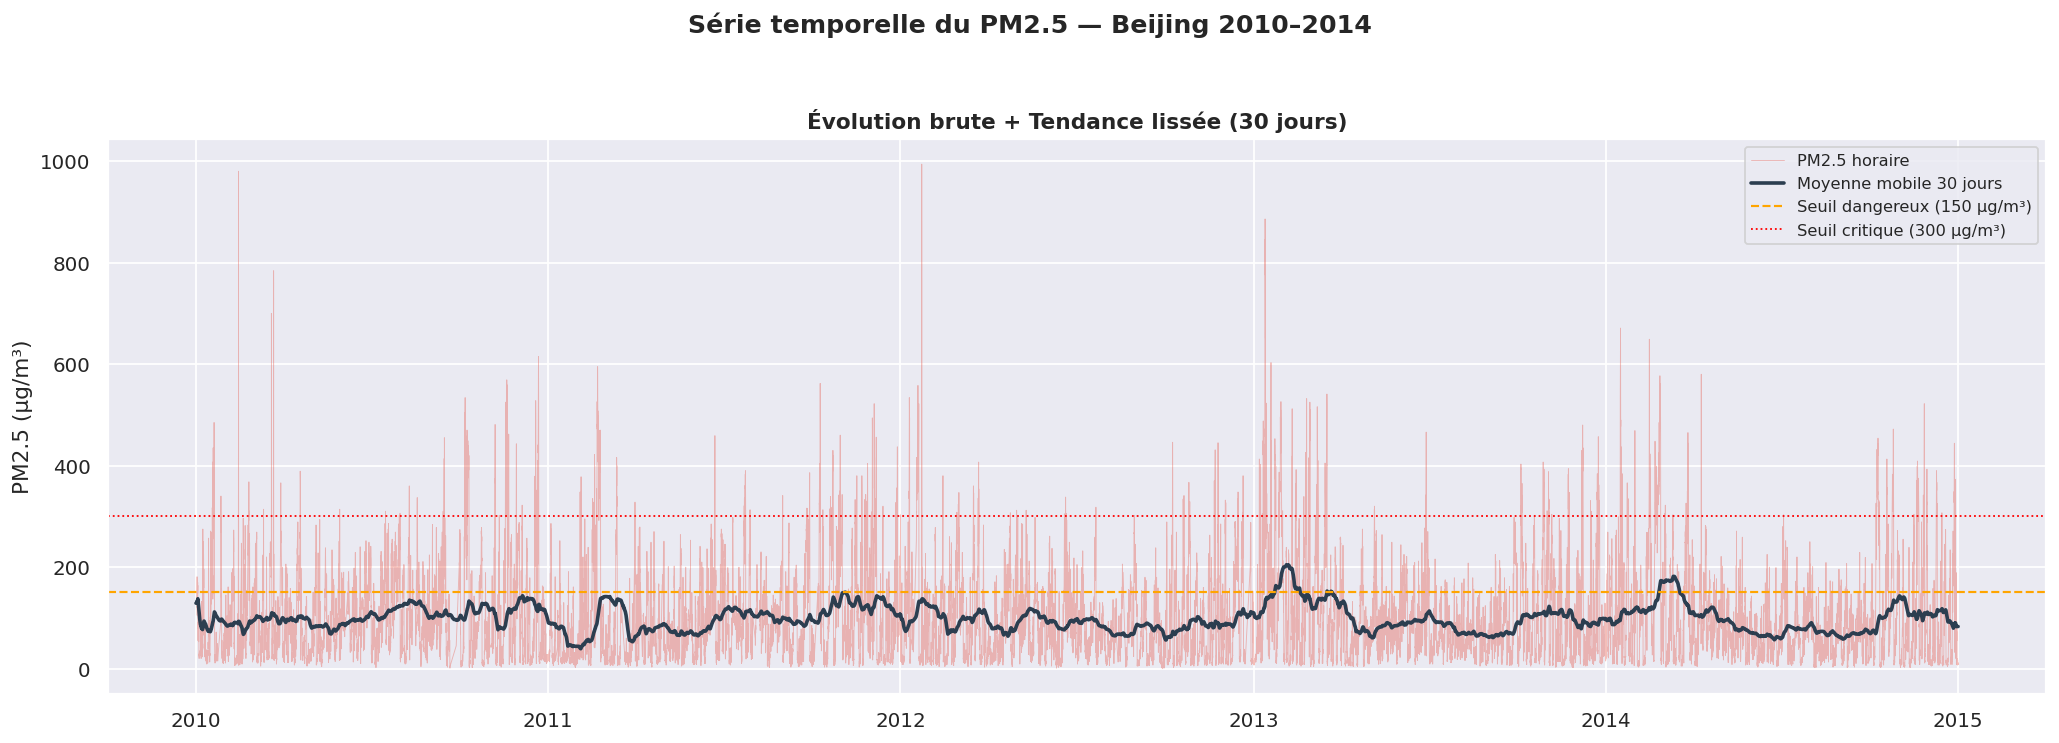

In [81]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

fig, ax1 = plt.subplots(figsize=(16, 6))
fig.suptitle("Série temporelle du PM2.5 — Beijing 2010–2014", fontsize=14, fontweight="bold")

# ── Série brute + moyenne mobile ─────────────────────────────
ax1.plot(df.index, df["pm25"],
         color="#E74C3C", alpha=0.35, linewidth=0.5,
         label="PM2.5 horaire")
roll_30d = df["pm25"].rolling("30D").mean()
ax1.plot(roll_30d.index, roll_30d,
         color="#2C3E50", linewidth=2,
         label="Moyenne mobile 30 jours")
ax1.axhline(150, color="orange", linestyle="--",
            linewidth=1.2, label="Seuil dangereux (150 µg/m³)")
ax1.axhline(300, color="red", linestyle=":",
            linewidth=1, label="Seuil critique (300 µg/m³)")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_title("Évolution brute + Tendance lissée (30 jours)", fontweight="bold")
ax1.legend(loc="upper right", fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.savefig("serie_brute_tendance.png", bbox_inches="tight")
plt.show()

Il ressort que:

*   **Volatilité et pics de pollution** : La ligne rouge claire (PM2.5 horaire) montre une très grande variabilité. Il y a de nombreux épisodes où la concentration de PM2.5 dépasse largement les seuils dangereux (ligne orange, 150 µg/m³) et même critiques (ligne rouge, 300 µg/m³). Ces pics sont souvent de courte durée mais peuvent atteindre des niveaux extrêmement élevés, comme l'ont montré les

*   **Saisonnalité prononcée** : La ligne sombre (moyenne mobile sur 30 jours) révèle une forte saisonnalité. Chaque année, on observe clairement :
    *   Des **périodes de forte pollution** (la moyenne mobile est élevée) pendant les mois d'hiver (fin d'année et début d'année suivante), où elle se maintient souvent au-dessus du seuil dangereux de 150 µg/m³.
    *   Des **périodes de faible pollution** (la moyenne mobile est basse) pendant les mois d'été (milieu d'année).

*   **Tendance annuelle** : Sur la période 2010-2014, la moyenne mobile suggère une légère diminution générale des niveaux de pollution sur la fin de la période, bien que des pics saisonniers persistent. Il n'y a pas de tendance linéaire forte à la baisse ou à la hausse sur l'ensemble des cinq ans, mais plutôt des fluctuations annuelles.

*   **Impact des seuils** : Les lignes des seuils (150 et 300 µg/m³) sont fréquemment franchies, surtout en hiver, ce qui indique que la qualité de l'air à Beijing est régulièrement problématique et nécessite une surveillance et des actions régulières.

### **2.3.2  PM2.5 moyen par année**

Ce graphique à barres présente la concentration moyenne annuelle de PM2.5 pour chaque année du dataset. Il permet d'identifier les variations annuelles et de voir si une amélioration ou une dégradation générale de la qualité de l'air est observée sur la période.

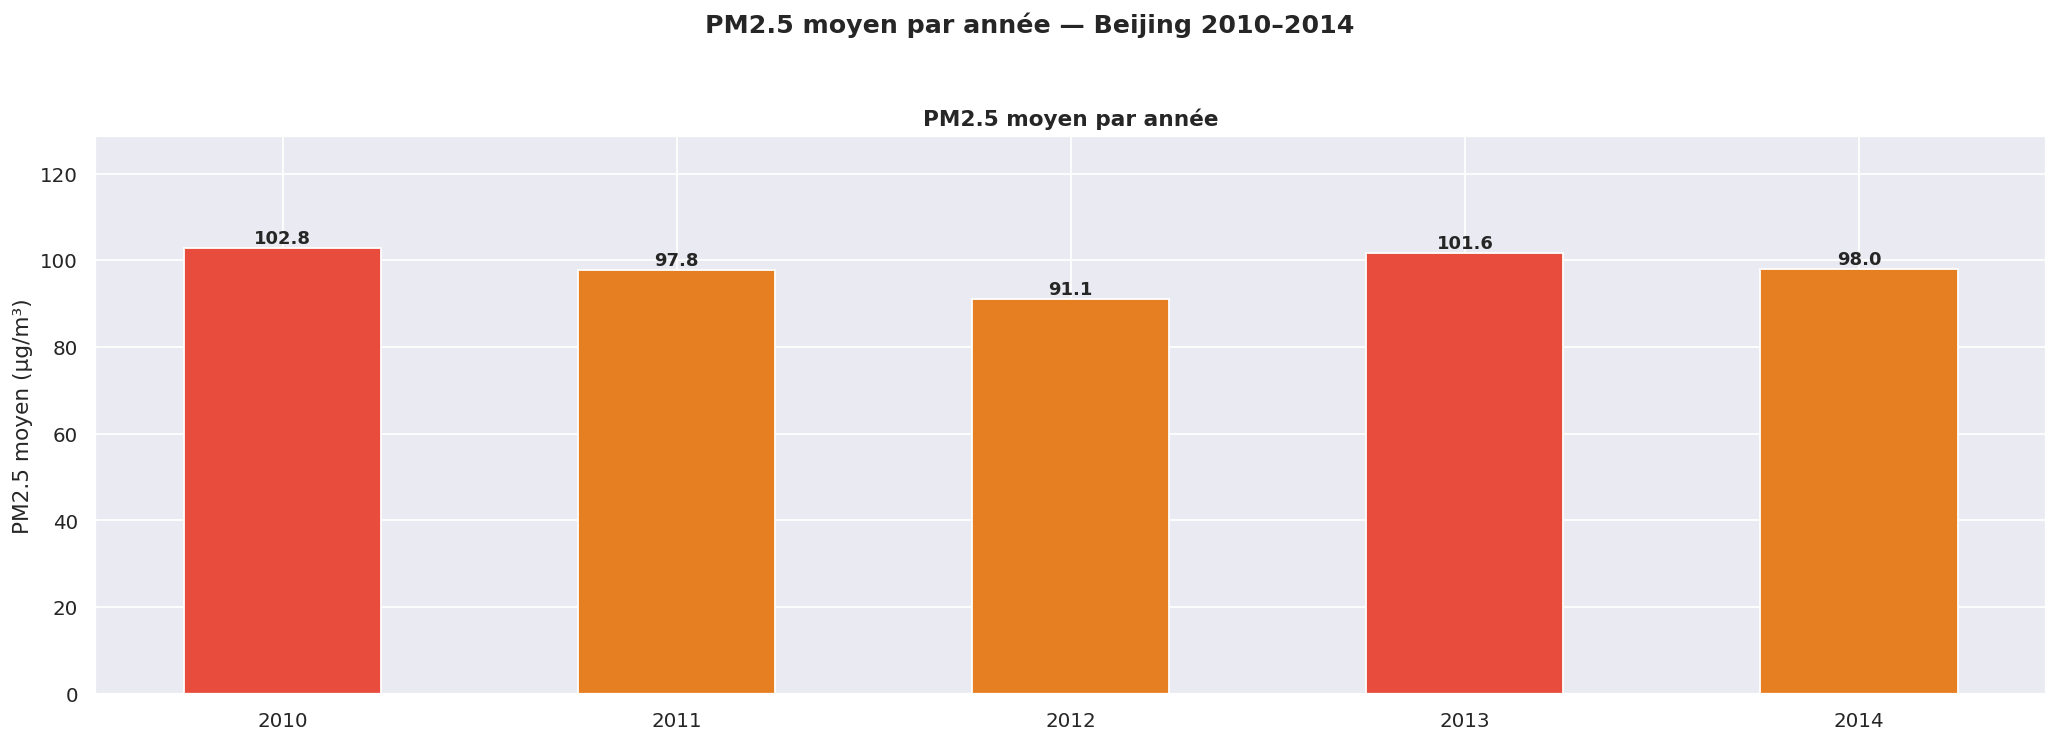

In [82]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

fig, ax2 = plt.subplots(figsize=(16, 6))
fig.suptitle("PM2.5 moyen par année — Beijing 2010–2014", fontsize=14, fontweight="bold")

# ── Moyenne annuelle ──────────────────────────────────────────
annual = df.groupby(df.index.year)["pm25"].mean()
colors_a = ["#27AE60" if v < 90 else "#E67E22"
            if v < 100 else "#E74C3C" for v in annual.values]
bars = ax2.bar(annual.index.astype(str), annual.values,
               color=colors_a, edgecolor="white", width=0.5)
for bar, val in zip(bars, annual.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{val:.1f}", ha="center",
             fontweight="bold", fontsize=10)
ax2.set_title("PM2.5 moyen par année", fontweight="bold")
ax2.set_ylabel("PM2.5 moyen (µg/m³)")
ax2.set_ylim(0, annual.max() * 1.25)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.savefig("pm25_annuel.png", bbox_inches="tight")
plt.show()

**Commentaire :**

Ce graphique à barres illustre la concentration moyenne annuelle de PM2.5 pour chaque année de notre dataset (2010-2014). Il nous permet d'observer la tendance générale de la pollution sur cette période :

*   **Fluctuations annuelles** : On observe des fluctuations dans les niveaux de PM2.5 d'une année sur l'autre. Les années 2010 et 2013 montrent des moyennes annuelles légèrement plus élevées, avec des valeurs autour de 100-103 µg/m³. En revanche, les années 2011, 2012 et 2014 affichent des moyennes légèrement plus basses, se situant entre 93 et 98 µg/m³.

*   **Pas de tendance linéaire nette** : Il n'y a pas de tendance linéaire forte et claire, ni à la baisse ni à la hausse, sur l'ensemble de la période de cinq ans. Cela suggère que, malgré les efforts ou les variations naturelles, les niveaux moyens de PM2.5 sont restés globalement élevés et variables d'une année à l'autre à Beijing pendant cette période.

*   **Persistance de niveaux élevés** : Même dans les années les moins polluées, les moyennes annuelles restent bien au-dessus des seuils de qualité de l'air recommandés (par exemple, l'OMS recommande une moyenne annuelle de 5 µg/m³ et ne pas dépasser 15 µg/m³ sur 24h). Cela confirme que la pollution aux PM2.5 est un problème persistant et significatif à Beijing.

Cette analyse annuelle complète la vue d'ensemble fournie par la série temporelle brute et la moyenne mobile en montrant comment les conditions saisonnières ou les politiques environnementales peuvent avoir un impact variable d'une année sur l'autre.

### **2.4  La saisonnalité multi-niveeaux**

###  **2.4.1   Saisonnalité annuelle**

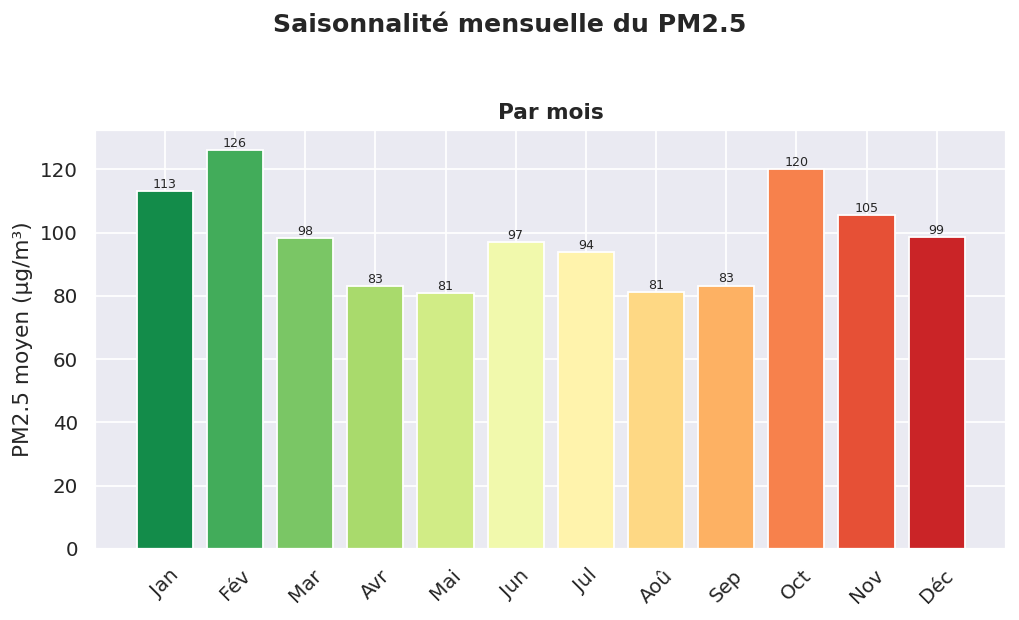

In [83]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

mois  = ["Jan","Fév","Mar","Avr","Mai","Jun",
          "Jul","Aoû","Sep","Oct","Nov","Déc"]

# ── Saisonnalité annuelle ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.suptitle("Saisonnalité mensuelle du PM2.5", fontsize=14, fontweight="bold")
monthly = df.groupby(df.index.month)["pm25"].mean()
bars1   = ax1.bar(mois, monthly.values,
                  color=sns.color_palette("RdYlGn_r", 12),
                  edgecolor="white")
ax1.set_title("Par mois", fontweight="bold")
ax1.set_ylabel("PM2.5 moyen (µg/m³)")
ax1.tick_params(axis="x", rotation=45)
for bar, val in zip(bars1, monthly.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{val:.0f}", ha="center", fontsize=7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("saisonnalite_mensuelle.png", bbox_inches="tight")
plt.show()

**Commentaire :**

Ce graphique à barres illustre la concentration moyenne de PM2.5 pour chaque mois de l'année. Il met clairement en évidence une forte saisonnalité dans les niveaux de pollution à Beijing :

**Pics de pollution en hiver** : On observe une augmentation significative des niveaux de PM2.5 durant les mois d'hiver (novembre, décembre, janvier, février et mars). Les mois de janvier et février affichent les moyennes les plus élevées, souvent au-dessus de 110 µg/m³ et même jusqu'à 126 µg/m³ en février. Cela est généralement dû à des facteurs tels que le chauffage au charbon, les conditions météorologiques défavorables à la dispersion des polluants (inversions de température, vents faibles) et une humidité accrue.

**Faible pollution en été** : À l'inverse, les mois d'été (mai à septembre) présentent les niveaux de PM2.5 les plus bas, avec des moyennes autour de 80-90 µg/m³. Durant cette période, les conditions météorologiques comme des vents plus forts et des pluies fréquentes favorisent la dispersion des particules, tandis que les sources de chauffage sont moins actives.

**Transitions** : Les mois de printemps (avril) et d'automne (octobre) agissent comme des périodes de transition, avec des niveaux de pollution intermédiaires.

### **2.4.2   Saisonnalité hebdomadaire**

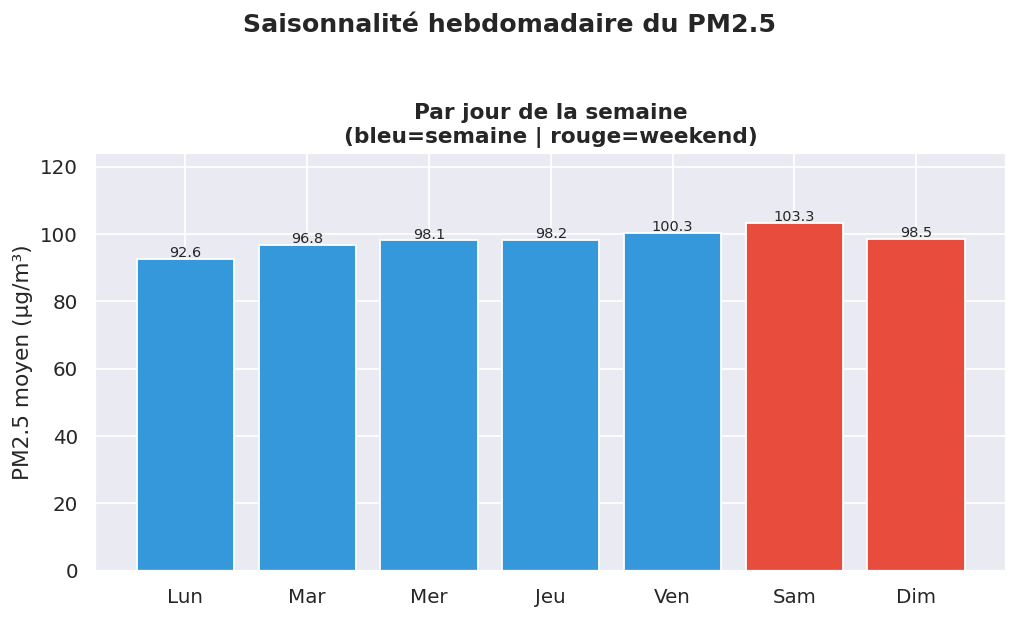

In [84]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

jours = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]

# ── Saisonnalité hebdomadaire ─────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.suptitle("Saisonnalité hebdomadaire du PM2.5", fontsize=14, fontweight="bold")
weekly   = df.groupby(df.index.dayofweek)["pm25"].mean()
colors_w = ["#3498DB" if i < 5 else "#E74C3C" for i in range(7)]
bars2    = ax2.bar(jours, weekly.values,
                   color=colors_w, edgecolor="white")
ax2.set_title("Par jour de la semaine\n(bleu=semaine | rouge=weekend)",
              fontweight="bold")
ax2.set_ylabel("PM2.5 moyen (µg/m³)")
ax2.set_ylim(0, weekly.max() * 1.2)
for bar, val in zip(bars2, weekly.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("saisonnalite_hebdomadaire.png", bbox_inches="tight")
plt.show()

**Commentaire :**

Ce graphique à barres illustre la concentration moyenne de PM2.5 pour chaque jour de la semaine. Il vise à identifier si la pollution suit un schéma particulier entre les jours ouvrables et le week-end :

**Légère augmentation le week-end** : On observe une tendance où les niveaux de PM2.5 sont légèrement plus élevés le week-end (samedi et dimanche) par rapport aux jours de semaine. Le samedi en particulier affiche la moyenne la plus haute.

**Jours de semaine stables** : Les jours de semaine (du lundi au vendredi) montrent des niveaux de PM2.5 relativement stables, avec des variations minimales entre eux.


### **2.4.3   Saisonnalité journalière**

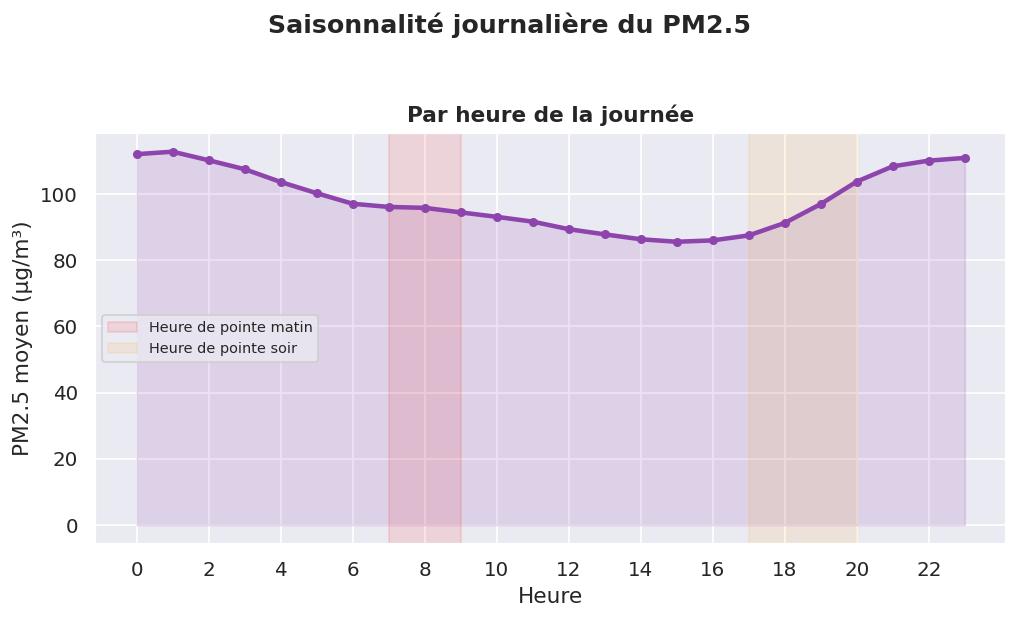

In [85]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

# ── Saisonnalité journalière ──────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 5))
fig3.suptitle("Saisonnalité journalière du PM2.5", fontsize=14, fontweight="bold")
hourly = df.groupby(df.index.hour)["pm25"].mean()
ax3.plot(hourly.index, hourly.values,
         color="#8E44AD", linewidth=2.5,
         marker="o", markersize=4)
ax3.fill_between(hourly.index, hourly.values,
                 alpha=0.15, color="#8E44AD")
ax3.axvspan(7, 9,   alpha=0.1, color="red",
            label="Heure de pointe matin")
ax3.axvspan(17, 20, alpha=0.1, color="orange",
            label="Heure de pointe soir")
ax3.set_title("Par heure de la journée", fontweight="bold")
ax3.set_ylabel("PM2.5 moyen (µg/m³)")
ax3.set_xlabel("Heure")
ax3.set_xticks(range(0, 24, 2))
ax3.legend(fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("saisonnalite_journaliere.png", bbox_inches="tight")
plt.show()

**Commentaire :**

Ce graphique révèle le **profil horaire moyen du PM2.5 sur l'ensemble
des 5 années** (2010–2014).

*  **Nuit et début de matinée (0h–6h) : niveaux élevés (~108–110 µg/m³)**

Contre-intuitivement, c'est **la nuit que la pollution est la plus forte**.
Ce phénomène s'explique par la **couche limite nocturne** : la nuit, en
l'absence de rayonnement solaire, l'atmosphère se stabilise et se refroidit.
La turbulence verticale disparaît, la hauteur de mélange s'effondre, et
les polluants émis par l'activité humaine (chauffage, industrie nocturne)
se concentrent dans une couche d'air très fine près du sol. Il n'y a
tout simplement nulle part où aller pour ces particules.



* **Matinée (6h–9h) : légère baisse puis stabilisation (~96–97 µg/m³)**

Dès le lever du soleil, le réchauffement du sol crée de la **convection
thermique** : l'air chaud monte, la hauteur de mélange augmente, et les
polluants se diluent dans un volume d'air plus grand. C'est ce qui explique
la baisse observée entre 4h et 8h. Cependant, cette amélioration est
**partiellement compensée** par les émissions des heures de pointe
matinales (trafic, démarrage de l'activité industrielle), d'où un
plateau autour de 7h–9h au lieu d'une poursuite de la baisse.


* **Journée (10h–16h) : minimum de pollution (~85–95 µg/m³)**

C'est le creux de la journée. Le soleil est au plus haut, la convection
thermique est maximale, la hauteur de mélange atmosphérique atteint son
pic. Les polluants se diluent dans le plus grand volume d'air disponible
de la journée. De plus, le rayonnement UV favorise certaines réactions
photochimiques qui dégradent une partie des polluants secondaires.

Le **minimum absolu se situe entre 15h et 16h** (~85 µg/m³), soit
une réduction de  ~ 23% par rapport au maximum nocturne; ce qui
représente une différence sanitaire très significative.


* **Soirée (17h–20h) : remontée rapide (+25 µg/m³ en 4 heures)**

La remontée vespérale est la plus **abrupte** du graphique. Elle est
provoquée par la conjonction de deux phénomènes simultanés :

 **Effondrement de la couche de mélange** : avec la perte du rayonnement
  solaire, la convection thermique cesse brutalement. La hauteur de
  mélange s'effondre, concentrant les polluants en suspension dans une
  couche de plus en plus fine.
 **Pic d'émissions vespérales** : les heures de pointe du soir (17h–20h,
  zone orange) coïncident exactement avec cet effondrement atmosphérique,
  créant un effet de double peine; plus d'émissions dans un volume d'air
  qui se réduit.


* **Nuit tombante (21h–23h) : plateau élevé (~108–110 µg/m³)**

La pollution rejoint rapidement son niveau nocturne de base. L'atmosphère
est de nouveau stable, la couche limite est à son minimum, et les
émissions de chauffage nocturne prennent le relais des émissions de trafic.


## **2.5  Décomposition STL, ACFF et Test ADF**

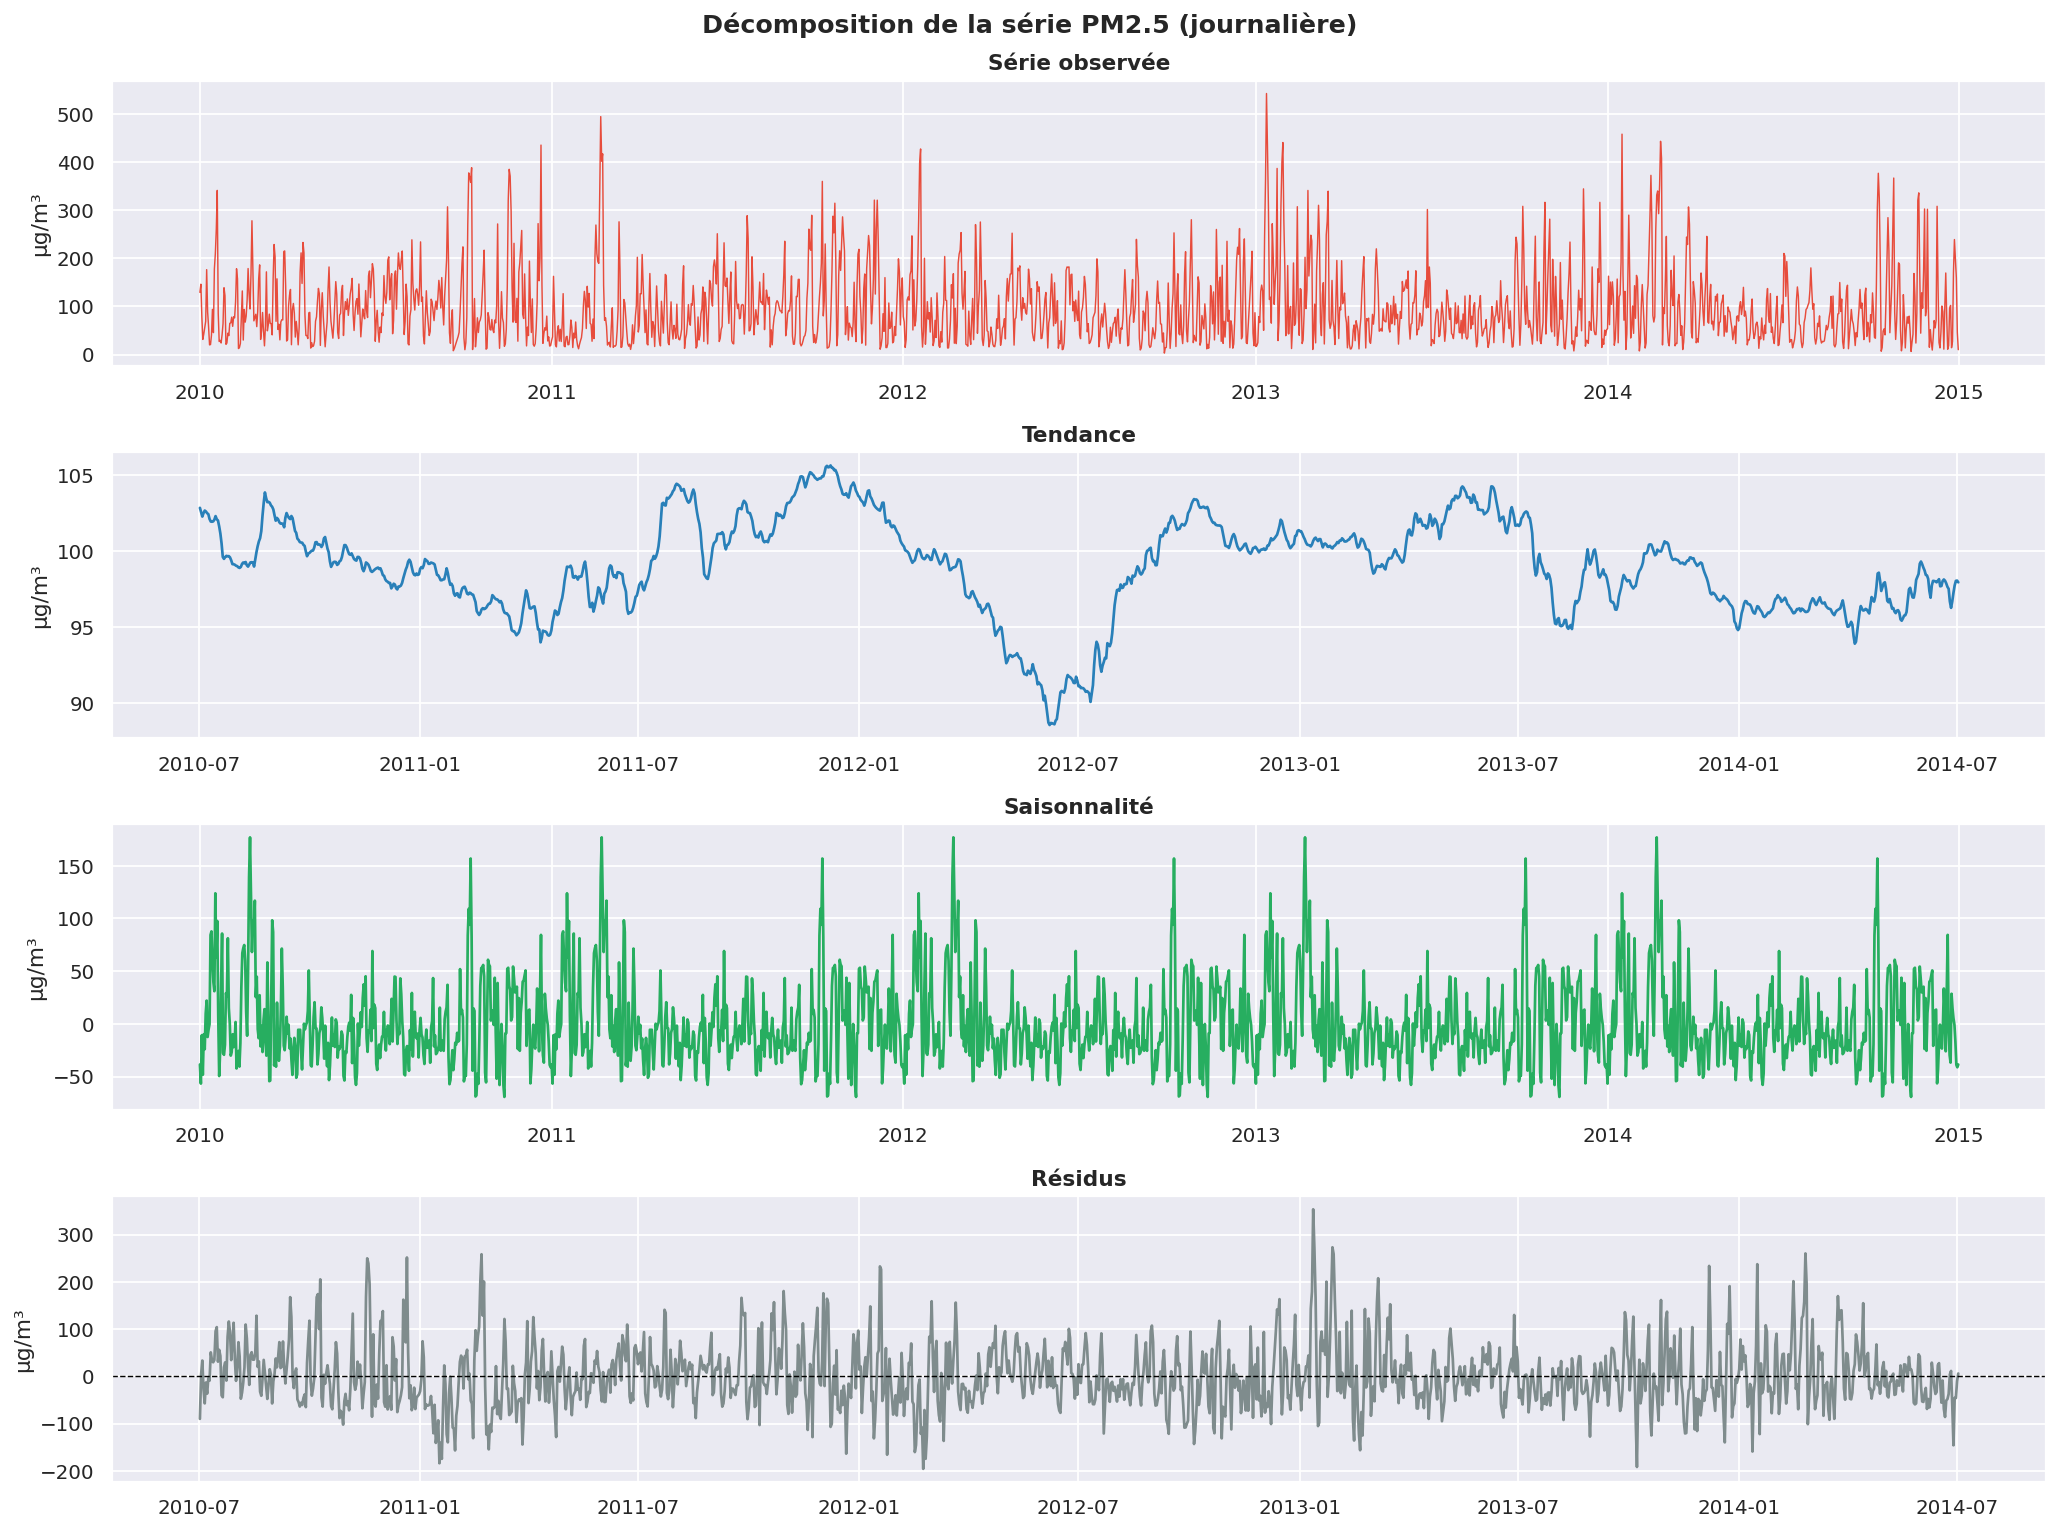

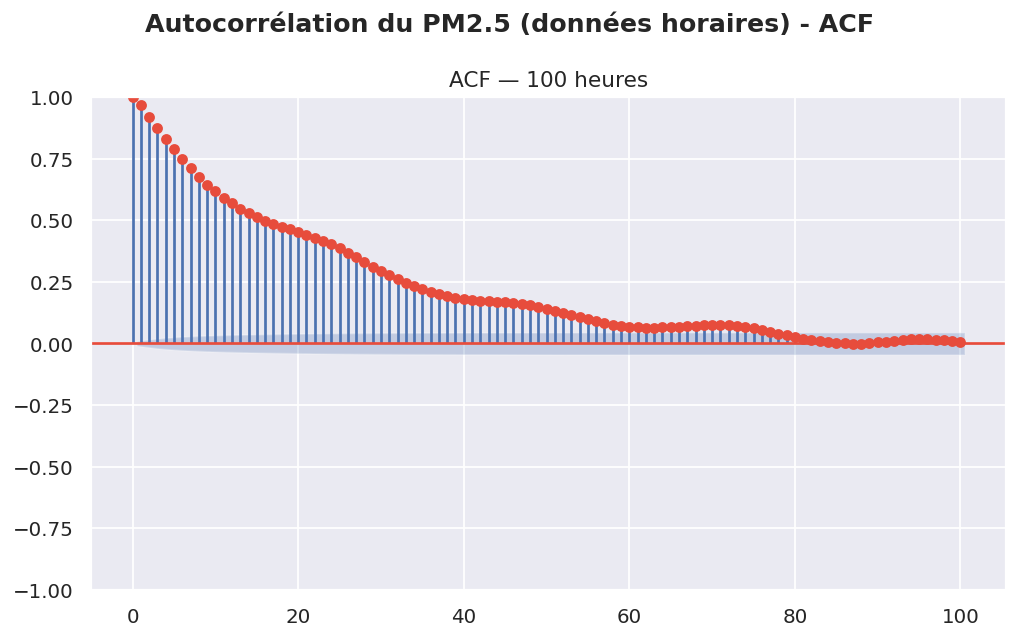

TEST DE STATIONNARITÉ — Augmented Dickey-Fuller
Statistique ADF  : -21.3471
p-value          : 0.0000000000
Valeurs critiques :
   1% : -3.4305
   5% : -2.8616
   10% : -2.5668

 Série STATIONNAIRE (p < 0.05) → pas de différenciation nécessaire


In [86]:
# @title
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ── Décomposition ─────────────────────────────────────────────
daily  = df["pm25"].resample("D").mean().interpolate()
decomp = seasonal_decompose(daily, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle("Décomposition de la série PM2.5 (journalière)",
             fontsize=14, fontweight="bold")

components = [
    (decomp.observed,  "Série observée", "#E74C3C"),
    (decomp.trend,     "Tendance",       "#2980B9"),
    (decomp.seasonal,  "Saisonnalité",   "#27AE60"),
    (decomp.resid,     "Résidus",        "#7F8C8D"),
]
for ax, (data, title, color) in zip(axes, components):
    lw = 0.8 if title == "Série observée" else 1.5
    ax.plot(data.index, data.values, color=color, linewidth=lw)
    if title == "Résidus":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("µg/m³")

plt.tight_layout()
plt.savefig("decomposition.png", bbox_inches="tight")
plt.show()

# ── ACF ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
fig2.suptitle("Autocorrélation du PM2.5 (données horaires) - ACF",
              fontsize=14, fontweight="bold")

plot_acf(df["pm25"].dropna(),  lags=100,
         ax=ax2, color="#E74C3C",
         title="ACF — 100 heures")

plt.tight_layout()
plt.savefig("acf.png", bbox_inches="tight")
plt.show()

# ── Test ADF ──────────────────────────────────────────────────
print("=" * 60)
print("TEST DE STATIONNARITÉ — Augmented Dickey-Fuller")
print("=" * 60)
adf = adfuller(df["pm25"].dropna())
print(f"Statistique ADF  : {adf[0]:.4f}")
print(f"p-value          : {adf[1]:.10f}")
print("Valeurs critiques :")
for k, v in adf[4].items():
    print(f"   {k} : {v:.4f}")
print()
if adf[1] < 0.05:
    print(" Série STATIONNAIRE (p < 0.05) "
          "→ pas de différenciation nécessaire")
else:
    print("⚠️  Série NON STATIONNAIRE → différenciation recommandée")

**Commentaire :**
### **1. Décomposition de la série (STL Decomposition)**
Le graphique de décomposition de la série PM2.5 (journalière) met en évidence quatre composantes :
*   **Série observée** : Représente la série PM2.5 brute, avec ses fluctuations importantes.
*   **Tendance** : Montre une tendance relativement stable sur l'ensemble de la période, avec des variations annuelles mais pas de décroissance ou croissance linéaire forte. On peut noter une légère diminution sur certaines périodes mais elle n'est pas constante.
*   **Saisonnalité** : Confirme une saisonnalité annuelle très prononcée, avec des hauts et des bas réguliers chaque année. Cela correspond aux observations précédentes de pics en hiver et de creux en été.
*   **Résidus** : C'est ce qui reste de la série après la suppression de la tendance et de la saisonnalité. Idéalement, les résidus devraient être un bruit blanc (sans structure). Ici, ils montrent encore une certaine variabilité, indiquant que le modèle additif simple ne capture pas toutes les dynamiques ou qu'il existe d'autres facteurs non expliqués.

### **2. Fonctions d'Autocorrélation (ACF)**

Le graphique ACF montre une décroissance très lente et progressive, restant significativement positive sur de nombreux lags. Cela indique une forte dépendance de la valeur actuelle du PM2.5 par rapport à ses valeurs passées lointaines, confirmant la présence d'une tendance et d'une saisonnalité à long terme. La structure en vagues de l'ACF est également un indicateur de saisonnalité.


### **3. Test de Stationnarité**
Le test ADF est utilisé pour vérifier si une série temporelle est stationnaire (c'est-à-dire si ses propriétés statistiques comme la moyenne et la variance ne changent pas au cours du temps). Les résultats sont les suivants :
*   **Statistique ADF (-21.3471)** : Cette valeur est très négative.
*   **p-value (0.000000)** : La p-value est extrêmement faible (proche de zéro) et bien inférieure au seuil de significativité courant (par exemple, 0.05).
*   **Valeurs critiques** : La statistique ADF est inférieure à toutes les valeurs critiques (-3.4305 à 1%, -2.8616 à 5%, -2.5668 à 10%).

**Conclusion du test ADF** : Étant donné que la p-value est très faible et que la statistique ADF est inférieure aux valeurs critiques, nous rejetons l'hypothèse nülle selon laquelle la série a une racine unitaire (c'est-à-dire qu'elle n'est pas stationnaire). Par conséquent, la série PM2.5 (journalière) est considérée comme **stationnaire**. Cela signifie qu'aucune différenciation (transformation qui rendrait la série stationnaire) n'est nécessaire.

## **2.6  Épisodes extrêmes, Corrélations et Boxplot saisonniers**

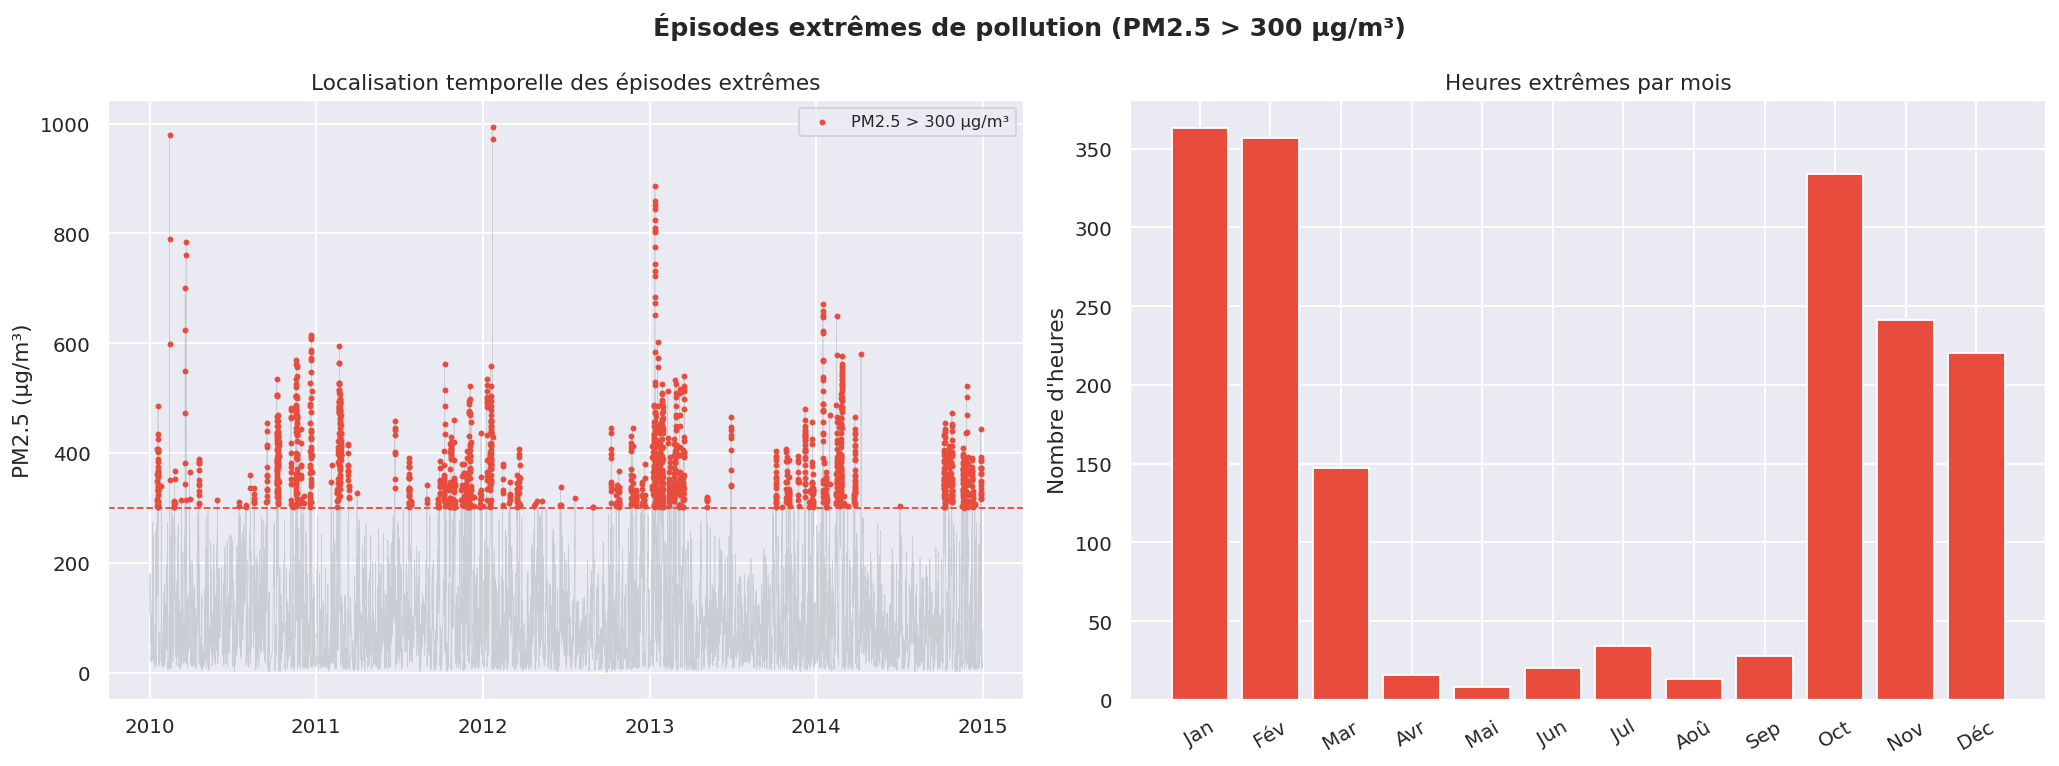

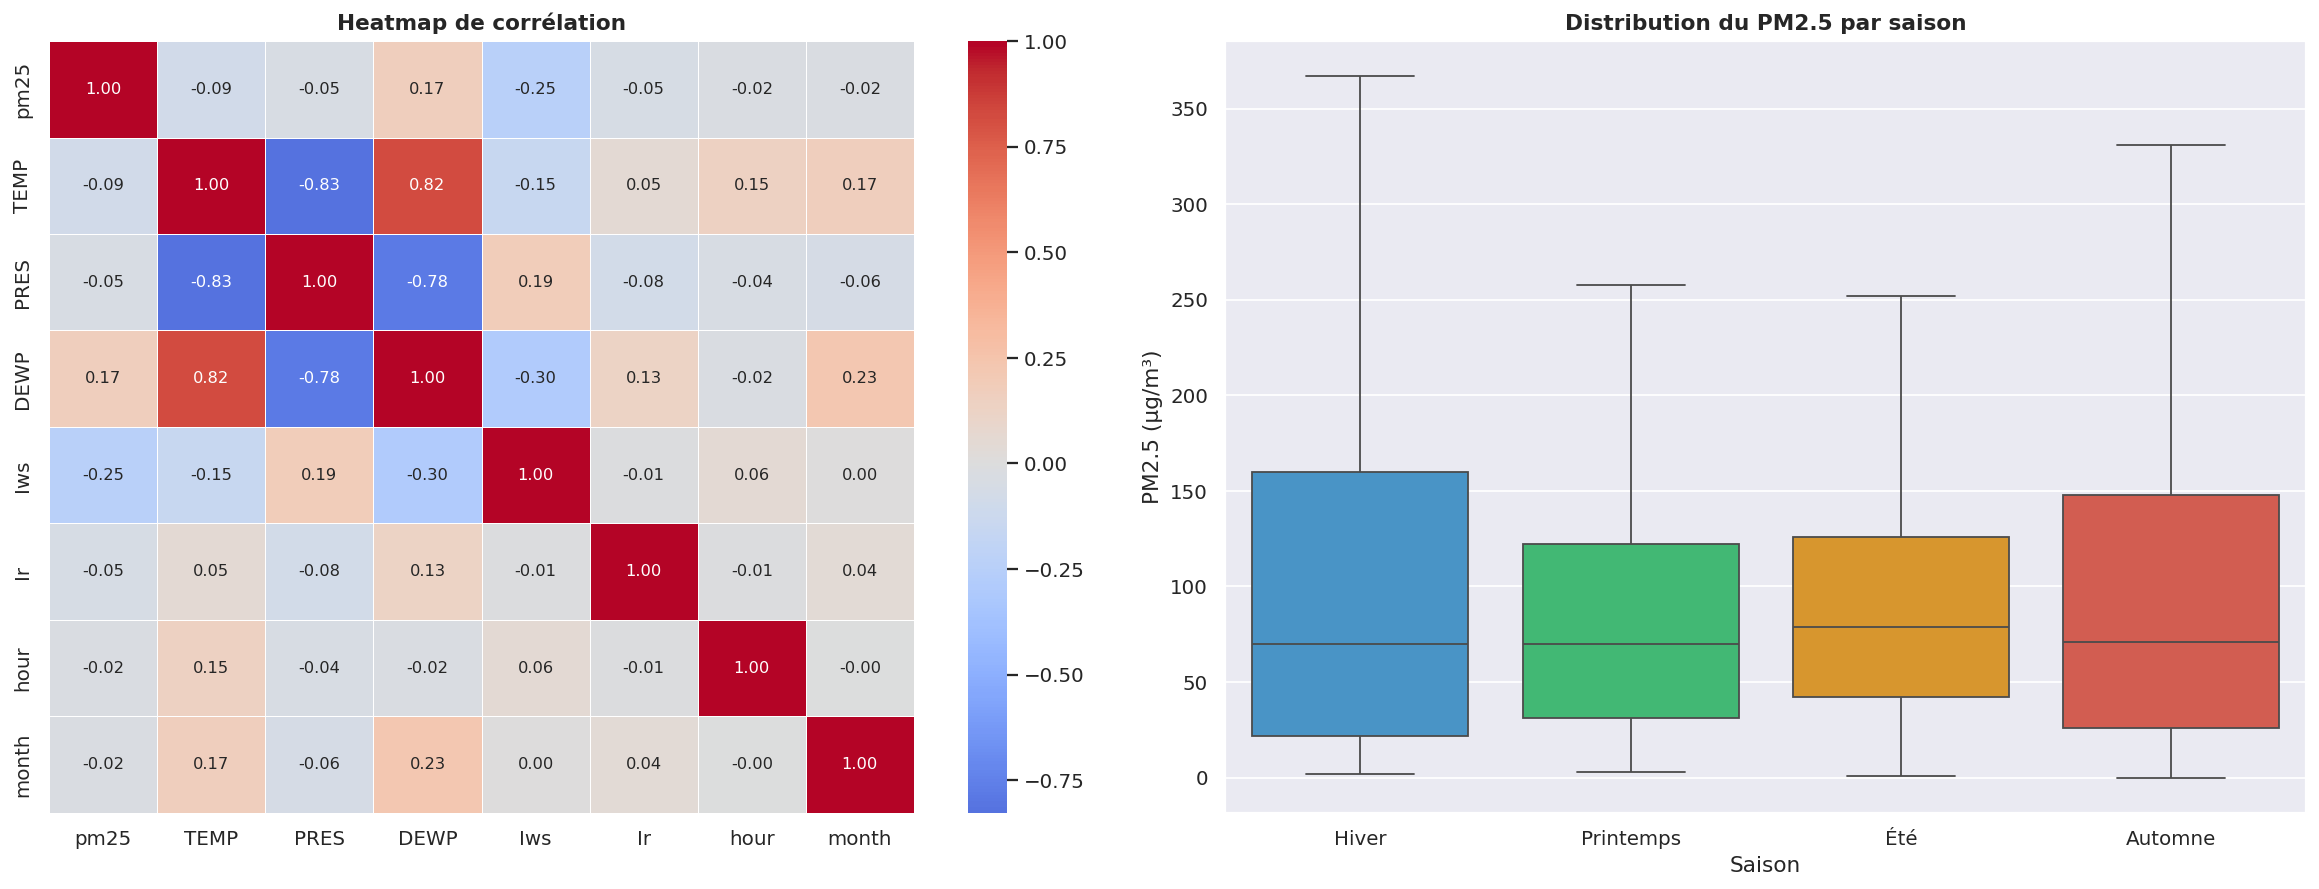

 STATISTIQUES DES ÉPISODES EXTRÊMES
Seuil retenu        : 300 µg/m³
Heures concernées   : 1,781 / 43,824 (4.1%)
Valeur maximale     : 994.0 µg/m³
Mois le plus touché : Jan


In [87]:
# @title
SEUIL = 300

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Épisodes extrêmes de pollution (PM2.5 > 300 µg/m³)",
             fontsize=14, fontweight="bold")

# ── Série avec épisodes en surbrillance ───────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["pm25"],
         color="#BDC3C7", linewidth=0.4, alpha=0.7)
extreme = df[df["pm25"] > SEUIL]
ax1.scatter(extreme.index, extreme["pm25"],
            color="#E74C3C", s=5, zorder=5,
            label=f"PM2.5 > {SEUIL} µg/m³")
ax1.axhline(SEUIL, color="#E74C3C",
            linestyle="--", linewidth=1)
ax1.set_title("Localisation temporelle des épisodes extrêmes")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.legend(fontsize=9)

# ── Distribution par mois ─────────────────────────────────────
ax2 = axes[1]
extreme_monthly = extreme.groupby(extreme.index.month).size()

mois  = ["Jan","Fév","Mar","Avr","Mai","Jun",
          "Jul","Aoû","Sep","Oct","Nov","Déc"]

extreme_monthly.index = [mois[i-1] for i in extreme_monthly.index]
ax2.bar(extreme_monthly.index, extreme_monthly.values,
        color="#E74C3C", edgecolor="white")
ax2.set_title("Heures extrêmes par mois")
ax2.set_ylabel("Nombre d'heures")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("episodes_extremes.png", bbox_inches="tight")
plt.show()

# ── Heatmap enrichie + Boxplot saisons ───────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))


cols_corr = ["pm25","TEMP","PRES","DEWP","Iws","Ir","hour","month"]
cols_corr = [c for c in cols_corr if c in df.columns]
corr      = df[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes2[0], linewidths=0.5,
            annot_kws={"size": 9})
axes2[0].set_title("Heatmap de corrélation",
                   fontweight="bold")

df["saison"] = df.index.month.map({
    12:"Hiver",  1:"Hiver",  2:"Hiver",
    3:"Printemps", 4:"Printemps", 5:"Printemps",
    6:"Été",     7:"Été",    8:"Été",
    9:"Automne", 10:"Automne", 11:"Automne"
})
ordre   = ["Hiver","Printemps","Été","Automne"]
palette = {"Hiver":"#3498DB","Printemps":"#2ECC71",
           "Été":"#F39C12","Automne":"#E74C3C"}

sns.boxplot(data=df, x="saison", y="pm25",
            order=ordre, palette=palette, hue="saison", legend=False,
            ax=axes2[1], showfliers=False)
axes2[1].set_title("Distribution du PM2.5 par saison",
                   fontweight="bold")
axes2[1].set_ylabel("PM2.5 (µg/m³)")
axes2[1].set_xlabel("Saison")

plt.tight_layout()
plt.savefig("meteo_pollution.png", bbox_inches="tight")
plt.show()

# ── Stats épisodes extrêmes ───────────────────────────────────
print("=" * 60)
print(" STATISTIQUES DES ÉPISODES EXTRÊMES")
print("=" * 60)
print(f"Seuil retenu        : {SEUIL} µg/m³")
print(f"Heures concernées   : {len(extreme):,} / {len(df):,} "
      f"({len(extreme)/len(df)*100:.1f}%)")
print(f"Valeur maximale     : {df['pm25'].max():.1f} µg/m³")
# Correction: Use extreme_monthly to find the most affected month
most_affected_month_name = extreme_monthly.idxmax() # Directly get the month name string
print(f"Mois le plus touché : {most_affected_month_name}")


## **3. Feature Engineering**


Le Feature Engineering est souvent **l'étape la plus déterminante** d'un
projet de Machine Learning. Un bon modèle avec de mauvaises features donnera
de mauvais résultats. À l'inverse, des features bien construites peuvent
transformer un modèle simple en un prédicteur puissant.

Dans notre cas, nous travaillons sur une **série temporelle horaire**; ce
qui impose des contraintes et des opportunités spécifiques que nous allons
exploiter méthodiquement.

## **Bilan de l'analyse exploratoire**

**1. La série PM2.5 est fortement autocorrélée → Lags & Moyennes glissantes**

Le graphique ACF a révélé quelque chose de fondamental : le PM2.5
de l'heure actuelle est **fortement corrélé au PM2.5 des heures précédentes**,
avec des autocorrélations significatives jusqu'à 80 lags (soit 80 heures).
Ce n'est pas une surprise; la pollution atmosphérique est un
phénomène inertiel : les particules fines ne disparaissent pas instantanément,
elles s'accumulent ou se dispersent progressivement.

Ce que cela signifie concrètement pour notre modèle : **si on ne lui donne
pas accès au passé récent de la pollution, il part aveugle**. Il essaiera
de prédire J+1 uniquement à partir de la météo, sans savoir si aujourd'hui
la pollution est déjà à 20 µg/m³ ou à 350 µg/m³, une information pourtant
décisive.


Nous allons créer deux familles de variables temporelles :

 Des **lags directs** (`pm25_lag_1h`, `pm25_lag_6h`, `pm25_lag_12h`,
`pm25_lag_24h`) qui donnent au modèle une "mémoire" des valeurs passées exactes de la pollution.
- Des **moyennes glissantes** (`pm25_roll_3h`, `pm25_roll_12h`,
`pm25_roll_24h`) qui lissent les fluctuations horaires et donnent au
modèle une vision de la **tendance récente** plutôt que d'un point isolé.
Une moyenne sur 24h qui monte progressivement est un signal très
différent d'une moyenne stable, même si la valeur instantanée est
identique.


**2. Une saisonnalité structurée à trois niveaux**

L'analyse de saisonnalité a mis en évidence trois cycles distincts et
superposés qui structurent fortement les niveaux de PM2.5 :

- **Cycle annuel** : l'hiver (Nov–Fév) est systématiquement plus pollué
  que l'été, avec un PM2.5 moyen qui peut être deux fois plus élevé.
  Le pic de Février (~ 125 µg/m³) contraste fortement avec le creux
  estival (~ 80–95 µg/m³). Ce cycle est lié aux inversions thermiques
  hivernales, au chauffage au charbon et à l'absence de pluies lessivantes.

- **Cycle hebdomadaire** : contrairement à ce qu'on pourrait attendre
  dans une ville industrielle, l'analyse par jour de la semaine ne révèle
  **pas de différence significative** entre semaine et weekend à Beijing.
  Les niveaux de PM2.5 sont quasi-identiques du lundi au dimanche. Cela
  s'explique par le fait que la pollution à Beijing est davantage pilotée
  par les **conditions météorologiques** (vent, température, pression)
  que par les seules émissions de trafic ou d'industrie. Le signal
  hebdomadaire existe donc, mais il est si faible qu'il apportera peu
  d'information prédictive au modèle.

- **Cycle journalier** : le graphique horaire révèle un profil contre-intuitif mais physiquement cohérent. La pollution est **maximale la nuit (0h–5h, ~ 108–110 µg/m³)** quand la couche limite
atmosphérique est au plus bas et que les polluants se concentrent près
du sol. Elle **décroît progressivement dans la matinée** grâce à la
convection thermique solaire, atteint son **minimum en milieu
d'après-midi (15h–16h, ~ 85 µg/m³)**, puis **remonte brutalement
en soirée (17h–20h)** sous l'effet combiné de l'effondrement de la
couche de mélange et des émissions vespérales. Contrairement à
l'hypothèse initiale, les heures de pointe matin (7h–9h) **ne
créent pas de pic**; elles ralentissent seulement la baisse naturelle.
Ces trois cycles sont **invisibles pour le modèle** si on ne lui fournit pas les variables temporelles correspondantes. Un modèle entraîné sans
`hour` ne pourra jamais distinguer une mesure de 3h du matin (~ 110 µg/m³ en moyenne) d'une mesure de 15h (~ 85 µg/m³ en moyenne), une différence de 25 µg/m³ qui est pourtant structurelle et prévisible.\
Nous allons extraire et encoder explicitement toutes
les dimensions temporelles pertinentes : `hour`, `month`, `dayofweek`,
`is_weekend` (binaire) et `saison` (catégorie). Même si le signal
hebdomadaire est faible, ces variables sont **gratuites à créer** (déjà dans l'index datetime) et laissons au modèle le soin de décider
de leur utilité via l'importance des features. La variable `hour` en
revanche est un **prédicteur fort** dont l'exclusion dégraderait
significativement la performance.


**3. Le vent est le premier facteur naturel de dispersion → Catégories de vent**

Avec une corrélation de -0.25 avec le PM2.5, la vitesse du vent (`Iws`) est
le prédicteur météo le plus puissant de notre dataset. La physique est simple :
un vent fort transporte et dilue les polluants, réduisant leur concentration.
Un air stagnant (calme ou vent faible) les laisse s'accumuler indéfiniment.

Mais voici ce qui est crucial : **la relation entre vitesse du vent et PM2.5
n'est pas linéaire**. Il existe un effet de seuil — en dessous d'environ
2 m/s, le vent n'a presque aucun effet dispersif. Entre 2 et 10 m/s, l'effet
augmente progressivement. Au-delà de 10 m/s, la dispersion est quasi-totale.
Une régression linéaire ne peut pas capturer cette non-linéarité, mais une
variable catégorielle, si.

De plus, la **direction du vent** (`cbwd`) est une variable catégorielle
qui encode l'origine géographique des masses d'air. Un vent du Nord-Est
peut amener de l'air industriel pollué depuis certaines régions, tandis
qu'un vent du Sud-Ouest peut amener de l'air plus propre. Cette information
directionnelle complète la vitesse.

Nous allons donc créer une variable `vent_cat` qui discrétise
la vitesse du vent en trois catégories physiquement significatives :
*calme* (< 2 m/s), *modéré* (2–10 m/s) et  *fort* (> 10 m/s). Cette
discrétisation capture les effets de seuil que la valeur brute ne permet
pas d'exprimer. Nous appliquerons également un **encodage One-Hot** à
`cbwd` pour rendre exploitable l'information directionnelle.


**4. Les inversions thermiques hivernales piègent les polluants**

La relation entre température et pollution est contre-intuitive au premier
abord : pourquoi fait-il plus froid ET plus pollué en même temps ? La réponse
est le phénomène d'**inversion thermique**. Normalement, l'air chaud monte
et emporte les polluants vers les couches supérieures de l'atmosphère. En
hiver, une couche d'air froid dense se forme au niveau du sol et reste
piégée sous une couche d'air chaud en altitude, créant un "couvercle"
atmosphérique qui empêche la dispersion verticale des polluants.

Ce phénomène est d'autant plus sévère que le refroidissement est progressif
et soutenu. Une seule mesure de température à un instant T ne suffit pas
à détecter une inversion thermique en cours, c'est la **tendance sur
plusieurs heures** qui est révélatrice.

De plus, la combinaison température + point de rosée (DEWP) donne une
information plus riche que la température seule. Un air froid et sec se
comporte différemment d'un air froid et humide en termes de dispersion
des polluants.

Ainsi, nous allons créer deux variables complémentaires :

 - `temp_feels_like` : combinaison de TEMP et DEWP via la formule du
  point de rosée ajusté, plus représentative des conditions atmosphériques
 réelles que la température brute.
>
 - `temp_roll_6h` : moyenne glissante de la température sur 6 heures,
  qui capture les tendances de refroidissement progressif précurseurs
d'inversion thermique. Une chute de 5°C en 6h est un signal d'alerte
  fort que la valeur instantanée seule ne permet pas d'exprimer.

 - `delta_temp` : variation de température entre l'heure actuelle et
   6 heures auparavant, un indicateur direct de refroidissement rapide.

**5. La pluie et la neige nettoient l'atmosphère**

La décomposition saisonnière et le boxplot par saison ont clairement montré
que l'été, saison de la mousson à Beijing, correspond aux niveaux de PM2.5
les plus bas. Ce n'est pas uniquement dû à la chaleur, mais aussi au
**lessivage atmosphérique** : les précipitations capturent les particules
fines en suspension et les précipitent au sol, réduisant rapidement et
significativement la concentration de PM2.5.

La neige a un effet similaire mais plus complexe : elle peut d'abord
capturer des particules puis, en fondant, les relâcher. De plus, les
épisodes neigeux coïncident souvent avec des conditions hivernales sévères
qui aggravent par ailleurs la pollution.

A cet effet, les variables `Ir` (heures de pluie cumulées) et `Is`
(heures de neige cumulées) seront conservées telles quelles dans le modèle.
Leur effet de lessivage est physiquement bien fondé et leur inclusion dans les features est directement justifiée par l'analyse exploratoire.
Nous pourrons également créer un indicateur binaire `is_rainy` (pluie
en cours ou récente) qui peut avoir un effet de seuil similaire à celui du vent.





**6. Des épisodes extrêmes existent et peuvent biaiser le modèle**

L'analyse des épisodes extrêmes a mis en évidence une réalité préoccupante :
**4.1% des heures dépassent 300 µg/m³**, avec un maximum absolu à **994 µg/m³**, soit 66 fois le seuil annuel recommandé par l'OMS. Ces valeurs extrêmes
correspondent à de véritables catastrophes sanitaires (épisodes de smog
dense en hiver), mais elles posent un problème technique sérieux pour
l'entraînement du modèle.

En présence de valeurs aussi extrêmes, un modèle de régression risque de
**sur-optimiser sur ces pics** au détriment de la performance sur les cas
courants. Il peut aussi apprendre des patterns aberrants associés à ces
événements exceptionnels qui ne sont pas généralisables.

La méthode **Winsorizing** est préférable à la simple suppression des
outliers : plutôt qu'éliminer les observations extrêmes (ce qui réduit
le volume de données), on les **plafonne** à un seuil raisonnable (par
exemple le percentile 99). L'observation est conservée mais sa valeur
extrême est atténuée.

Nous appliquerons un Winsorizing basé sur l'IQR
(Inter-Quartile Range) sur la variable cible `pm25_next_day`. Les valeurs
au-delà du percentile 99 seront plafonnées. Cela préserve la structure
des données tout en protégeant le modèle contre l'influence démesurée
des cas extrêmes.


**7. La cible est le lendemain, pas aujourd'hui → Décalage temporel strict**

Notre objectif  est de permettre à la ville d'**anticiper**
les épisodes de pollution, pas de les constater une fois qu'ils sont là.
Cela impose une contrainte absolue sur la construction des features :
**toute information utilisée comme feature doit être connue au moment
de la prédiction**, c'est-à-dire aujourd'hui à 23h, avant que le lendemain ne commence.

Cette contrainte peut souvent être violée par inadvertance, c'est ce qu'on appelle le **data leakage** (fuite de données du futur vers le passé). Par exemple, utiliser le PM2.5 de 14h le jour J pour prédire le PM2.5 moyen du jour J+1 est une fuite :
à minuit, on ne connaît pas encore la valeur de 14h du lendemain.

A cet effet, la variable cible sera `pm25_next_day = PM2.5(t + 24h)`,
c'est-à-dire la valeur de PM2.5 **24 heures plus tard**. Toutes nos
features (lags, rolling, variables météo) seront construites à partir de
données antérieures ou simultanées à l'instant t. Aucune information
future ne sera utilisée


**8. Les corrélations linéaires sont faibles → Modèles non-linéaires & interactions**

La heatmap de corrélation a révélé une limitation structurelle importante :
**aucune variable météo seule n'est fortement corrélée au PM2.5** (maximum -0.25 pour le vent). Cela ne signifie pas que ces variables sont inutiles,
mais que leur effet sur la pollution est **conditionnel et interactif**.

Par exemple : un vent fort réduit la pollution, mais seulement s'il n'y a pas simultanément une forte pression atmosphérique qui bloque la dispersion
verticale. Une température basse aggrave la pollution, mais seulement si
elle s'accompagne d'un point de rosée élevé et d'un vent faible. Ce sont
des **interactions à plusieurs variables** qu'une corrélation linéaire
bivariée ne peut pas capturer.

Deux implications directes :

- Nous allons créer des **features d'interaction** explicites comme
`temp_x_vent` (produit de la température et de la vitesse du vent)
 pour aider les modèles linéaires à capturer ces effets combinés.
 - Nous allons privilégier des **modèles non-linéaires** qui savent naturellement construire ces interactions et utiliser la régression linéaire uniquement comme baseline de référence.

### **3.1 Variables temporelles**

In [88]:
# @title
print("=" * 60)
print("3.1 — VARIABLES TEMPORELLES")
print("=" * 60)

# Variables temporelles de base
df["hour"]      = df.index.hour
df["day"]       = df.index.day
df["month"]     = df.index.month
df["dayofweek"] = df.index.dayofweek        # 0=Lundi … 6=Dimanche
df["is_weekend"]= (df.index.dayofweek >= 5).astype(int)
df["saison"]    = df.index.month.map({
    12:"Hiver",  1:"Hiver",   2:"Hiver",
    3:"Printemps", 4:"Printemps", 5:"Printemps",
    6:"Été",     7:"Été",     8:"Été",
    9:"Automne", 10:"Automne", 11:"Automne"
})

print("Variables créées :")
print(f"   - hour       : {df['hour'].unique()[:5]} ...")
print(f"   - dayofweek  : {df['dayofweek'].unique()}")
print(f"   - is_weekend : {df['is_weekend'].value_counts().to_dict()}")
print(f"   - saison     : {df['saison'].value_counts().to_dict()}")

3.1 — VARIABLES TEMPORELLES
Variables créées :
   - hour       : [0 1 2 3 4] ...
   - dayofweek  : [4 5 6 0 1 2 3]
   - is_weekend : {0: 31296, 1: 12528}
   - saison     : {'Printemps': 11040, 'Été': 11040, 'Automne': 10920, 'Hiver': 10824}


### **3.2 Variables météo dérivées**


In [89]:
# @title
print("=" * 60)
print("3.2 — VARIABLES MÉTÉO DÉRIVÉES")
print("=" * 60)

# ── Température ressentie (formule de Steadman simplifiée)

"""
La formule de Steadman simplifiée permet de calculer l'indice de chaleur (Heat Index)
ou la température ressentie en combinant la température de l'air
et l'humidité relative.
"""

# Combine TEMP et DEWP pour mieux représenter le stress thermique
df["temp_feels_like"] = (
    df["TEMP"] + 0.33 * (df["DEWP"] / 100 * 6.105 *
    np.exp(17.27 * df["TEMP"] / (237.7 + df["TEMP"]))) - 4.0
).round(2)

# ── Delta température (refroidissement rapide) ────────────────
# Variation de T° entre maintenant et il y a 6h
# Signal précurseur d'inversion thermique
df["delta_temp"] = (df["TEMP"] - df["TEMP"].shift(6)).round(2)

# ── Catégorie de vent (effets de seuil physiques) ─────────────
# < 2 m/s  : calme   → pas de dispersion
# 2–10 m/s : modéré  → dispersion partielle
# > 10 m/s : fort    → dispersion quasi-totale
df["vent_cat"] = pd.cut(
    df["Iws"],
    bins=[-np.inf, 2, 10, np.inf],
    labels=["calme", "modéré", "fort"]
)

# ── Indicateur binaire pluie récente ─────────────────────────
df["is_rainy"] = (df["Ir"] > 0).astype(int)

# ── Feature d'interaction : température × vent ───────────────
# Capture l'effet combiné : air froid + vent faible = pollution max
df["temp_x_vent"] = (df["TEMP"] * df["Iws"]).round(2)

# ── Feature d'interaction : pression × point de rosée ────────
# Anticyclone + air humide = conditions bloquantes maximales
df["pres_x_dewp"] = (df["PRES"] * df["DEWP"]).round(2)

print("Variables créées :")
cols_new = ["temp_feels_like","delta_temp","vent_cat",
            "is_rainy","temp_x_vent","pres_x_dewp"]
for col in cols_new:
    print(f"   - {col:<20} | ex: {df[col].dropna().iloc[0]}")

3.2 — VARIABLES MÉTÉO DÉRIVÉES
Variables créées :
   - temp_feels_like      | ex: -15.18
   - delta_temp           | ex: 2.0
   - vent_cat             | ex: calme
   - is_rainy             | ex: 0
   - temp_x_vent          | ex: -19.69
   - pres_x_dewp          | ex: -21441.0


### **3.3 Moyennes glissantes**


In [90]:
# @title
print("=" * 60)
print("3.3 — MOYENNES GLISSANTES (Rolling Means)")
print("=" * 60)

# ── Rolling PM2.5 ─────────────────────────────────────────────
# Court terme : tendance sur 3h (bruit filtré)
df["pm25_roll_3h"]  = df["pm25"].rolling(window=3,
                        min_periods=1).mean().round(2)
# Moyen terme : tendance sur 12h (demi-journée)
df["pm25_roll_12h"] = df["pm25"].rolling(window=12,
                        min_periods=1).mean().round(2)
# Long terme : tendance sur 24h (journée complète)
df["pm25_roll_24h"] = df["pm25"].rolling(window=24,
                        min_periods=1).mean().round(2)

# ── Rolling Température ───────────────────────────────────────
# Tendance de refroidissement sur 6h
# Précurseur d'inversion thermique
df["temp_roll_6h"]  = df["TEMP"].rolling(window=6,
                        min_periods=1).mean().round(2)

# ── Rolling Vent ──────────────────────────────────────────────
# Tendance du vent sur 6h
# Un vent qui faiblit progressivement = signal d'accumulation
df["iws_roll_6h"]   = df["Iws"].rolling(window=6,
                        min_periods=1).mean().round(2)

print("Variables créées :")
rolling_cols = ["pm25_roll_3h","pm25_roll_12h","pm25_roll_24h",
                "temp_roll_6h","iws_roll_6h"]
print(df[rolling_cols].describe().round(2))

3.3 — MOYENNES GLISSANTES (Rolling Means)
Variables créées :
       pm25_roll_3h  pm25_roll_12h  pm25_roll_24h  temp_roll_6h  iws_roll_6h
count      43824.00       43824.00       43824.00      43824.00     43824.00
mean          98.26          98.28          98.29         12.45        23.87
std           89.44          83.27          76.99         12.05        47.50
min            0.67           2.33           2.92        -17.83         0.74
25%           31.33          36.50          42.46          1.67         2.98
50%           73.67          76.86          79.04         13.67         7.45
75%          135.60         133.25         131.41         23.00        21.24
max          865.33         804.58         646.77         40.50       575.70


### **3.4 Lags temporels**


In [91]:
# @title
print("=" * 60)
print("3.4 — LAGS TEMPORELS")
print("=" * 60)

# ── Lags PM2.5 ────────────────────────────────────────────────
# Valeur exacte il y a 1h  → bruit de fond immédiat
df["pm25_lag_1h"]  = df["pm25"].shift(1)
# Valeur exacte il y a 6h  → tendance demi-journée
df["pm25_lag_6h"]  = df["pm25"].shift(6)
# Valeur exacte il y a 12h → tendance journée
df["pm25_lag_12h"] = df["pm25"].shift(12)
# Valeur exacte il y a 24h → même heure hier (saisonnalité journalière)
df["pm25_lag_24h"] = df["pm25"].shift(24)

print(" Lags créés :")
lag_cols = ["pm25_lag_1h","pm25_lag_6h","pm25_lag_12h","pm25_lag_24h"]
print(f"\n{'Variable':<20} {'NaN créés':>10} {'% NaN':>8}")
print("-" * 42)
for col in lag_cols:
    n_nan = df[col].isnull().sum()
    pct   = n_nan / len(df) * 100
    print(f"{col:<20} {n_nan:>10,} {pct:>7.2f}%")

print(f"\n Les NaN sont normaux : ils correspondent aux premières")
print(f"   heures du dataset pour lesquelles le passé est inconnu.")
print(f"   Ils seront supprimés lors du split train/test.")

3.4 — LAGS TEMPORELS
 Lags créés :

Variable              NaN créés    % NaN
------------------------------------------
pm25_lag_1h                   1    0.00%
pm25_lag_6h                   6    0.01%
pm25_lag_12h                 12    0.03%
pm25_lag_24h                 24    0.05%

 Les NaN sont normaux : ils correspondent aux premières
   heures du dataset pour lesquelles le passé est inconnu.
   Ils seront supprimés lors du split train/test.


### **3.5 Variable cible : pm25_next_day**


In [92]:
# @title
print("=" * 60)
print("3.5 — VARIABLE CIBLE : pm25_next_day")
print("=" * 60)

# ── Création de la cible J+1 ─────────────────────────────────
# pm25_next_day(t) = pm25(t + 24h)
# On décale de -24 pour "regarder en avant"
df["pm25_next_day"] = df["pm25"].shift(-24)

print(" Variable cible créée : pm25_next_day = PM2.5(t + 24h)")
print(f"\n Distribution de la cible :")
print(df["pm25_next_day"].describe().round(2))

print(f"\n  NaN en fin de série : {df['pm25_next_day'].isnull().sum()}")
print(f"   (les 24 dernières heures n'ont pas de J+1 connu)")
print(f"   → Elles seront supprimées automatiquement lors du dropna()")

3.5 — VARIABLE CIBLE : pm25_next_day
 Variable cible créée : pm25_next_day = PM2.5(t + 24h)

 Distribution de la cible :
count    43800.00
mean        98.24
std         90.97
min          0.00
25%         30.00
50%         73.00
75%        136.00
max        994.00
Name: pm25_next_day, dtype: float64

  NaN en fin de série : 24
   (les 24 dernières heures n'ont pas de J+1 connu)
   → Elles seront supprimées automatiquement lors du dropna()


### **3.6 Traitement des valeurs aberrantes : Winsorizing**


Le *Winsorizing* (ou winsorisation) est une technique statistique utilisée pour limiter l'influence des valeurs aberrantes (outliers) dans un ensemble de données.

Contrairement à d'autres méthodes qui suppriment simplement les données extrêmes, la winsorisation les remplace par des valeurs moins extrêmes situées à des seuils définis.

 3.6 — TRAITEMENT OUTLIERS : Winsorizing
Avant Winsorizing :
   Percentile 99 : 418.0 µg/m³
   Maximum       : 994.0 µg/m³
   Observations > P99 : 432

Après Winsorizing :
   Percentile 99 : 418.0 µg/m³
   Nouveau maximum : 418.0 µg/m³
   Réduction du max : 576.0 µg/m³


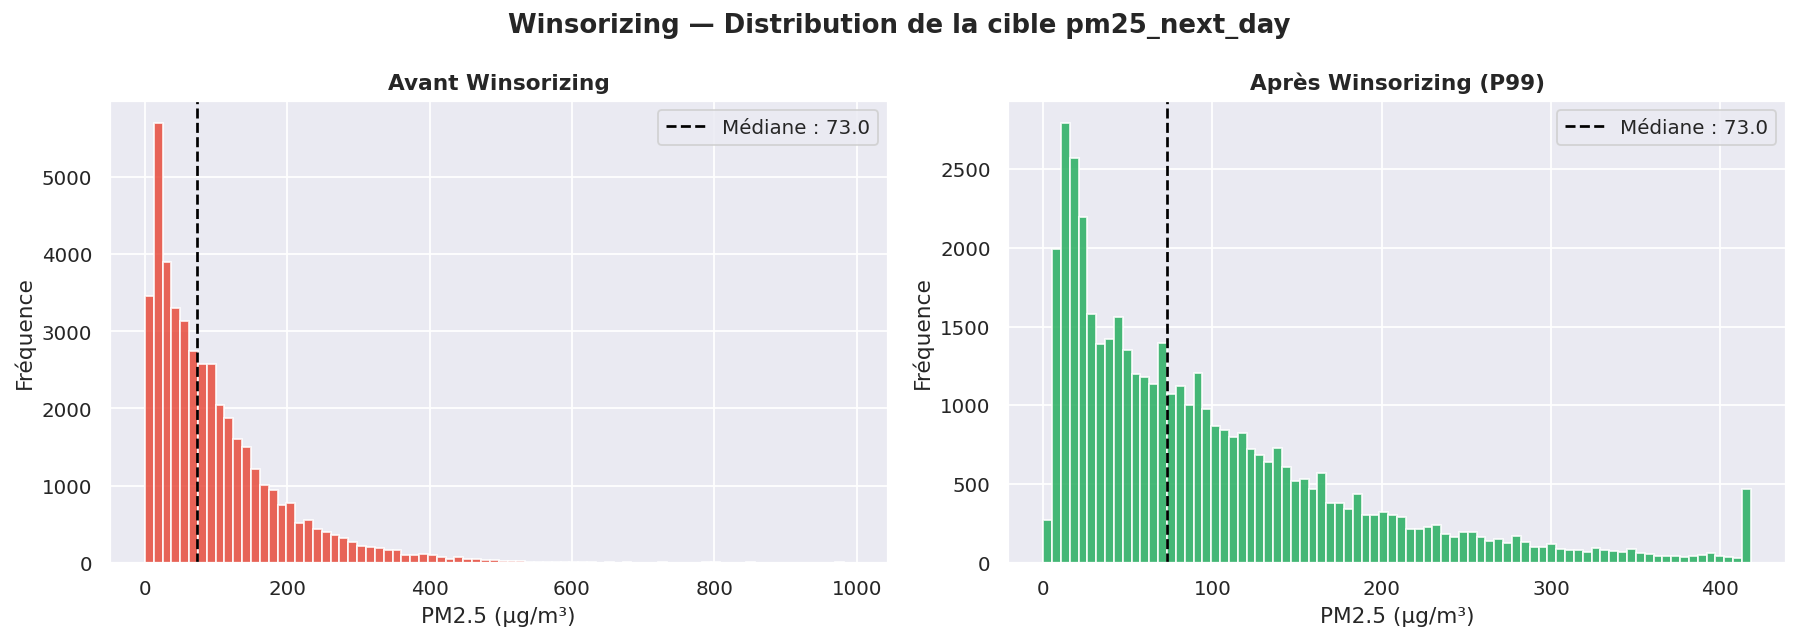

Winsorizing appliqué avec succès


In [93]:
# @title
print("=" * 60)
print(" 3.6 — TRAITEMENT OUTLIERS : Winsorizing")
print("=" * 60)

# ── Avant Winsorizing ─────────────────────────────────────────
p99_avant = df["pm25_next_day"].quantile(0.99)
max_avant = df["pm25_next_day"].max()
print(f"Avant Winsorizing :")
print(f"   Percentile 99 : {p99_avant:.1f} µg/m³")
print(f"   Maximum       : {max_avant:.1f} µg/m³")
print(f"   Observations > P99 : "
      f"{(df['pm25_next_day'] > p99_avant).sum():,}")

# ── Application du Winsorizing ────────────────────────────────
# On plafonne à P99 — les valeurs sont conservées mais atténuées
df["pm25_next_day_wins"] = df["pm25_next_day"].clip(
    upper=df["pm25_next_day"].quantile(0.99)
)

# ── Après Winsorizing ─────────────────────────────────────────
p99_apres = df["pm25_next_day_wins"].quantile(0.99)
max_apres = df["pm25_next_day_wins"].max()
print(f"\nAprès Winsorizing :")
print(f"   Percentile 99 : {p99_apres:.1f} µg/m³")
print(f"   Nouveau maximum : {max_apres:.1f} µg/m³")
print(f"   Réduction du max : {max_avant - max_apres:.1f} µg/m³")

# ── Visualisation avant/après ─────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Winsorizing — Distribution de la cible pm25_next_day",
             fontweight="bold")

for ax, col, titre, color in zip(
    axes,
    ["pm25_next_day", "pm25_next_day_wins"],
    ["Avant Winsorizing", "Après Winsorizing (P99)"],
    ["#E74C3C", "#27AE60"]
):
    ax.hist(df[col].dropna(), bins=80,
            color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].median(), color="black",
               linestyle="--", linewidth=1.5,
               label=f"Médiane : {df[col].median():.1f}")
    ax.set_title(titre, fontweight="bold")
    ax.set_xlabel("PM2.5 (µg/m³)")
    ax.set_ylabel("Fréquence")
    ax.legend()

plt.tight_layout()
plt.savefig("winsorizing.png", bbox_inches="tight")
plt.show()
print("Winsorizing appliqué avec succès")

### **3.7 Encodage des variables catégorielles**


In [94]:
# @title
print("=" * 60)
print(" 3.7 — ENCODAGE ONE-HOT : cbwd & vent_cat")
print("=" * 60)

# ── Distribution avant encodage ───────────────────────────────
print("Distribution cbwd :")
print(df["cbwd"].value_counts())
print("\nDistribution vent_cat :")
print(df["vent_cat"].value_counts())

# ── One-Hot Encoding ──────────────────────────────────────────
cbwd_dummies   = pd.get_dummies(df["cbwd"],
                                prefix="wind_dir",
                                drop_first=True)
vent_dummies   = pd.get_dummies(df["vent_cat"],
                                prefix="vent",
                                drop_first=True)
saison_dummies = pd.get_dummies(df["saison"],
                                prefix="saison",
                                drop_first=True)

df = pd.concat([df, cbwd_dummies, vent_dummies, saison_dummies],
               axis=1)

print(f"\n Colonnes One-Hot créées :")
new_cols = (list(cbwd_dummies.columns) +
            list(vent_dummies.columns) +
            list(saison_dummies.columns))
for col in new_cols:
    print(f"   + {col}")

 3.7 — ENCODAGE ONE-HOT : cbwd & vent_cat
Distribution cbwd :
cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

Distribution vent_cat :
vent_cat
fort      17060
calme     13756
modéré    13008
Name: count, dtype: int64

 Colonnes One-Hot créées :
   + wind_dir_NW
   + wind_dir_SE
   + wind_dir_cv
   + vent_modéré
   + vent_fort
   + saison_Hiver
   + saison_Printemps
   + saison_Été


### **3.8 Bilan final**


In [95]:
# @title
print("=" * 60)
print(" 3.8 — BILAN FINAL DU FEATURE ENGINEERING")
print("=" * 60)

# ── Suppression des NaN (lags + cible) ───────────────────────
# On utilise la cible Winsorisée pour la modélisation
df_model = df.copy()
df_model = df_model.dropna(subset=["pm25_next_day_wins"])

# Features finales retenues pour la modélisation
features = [
    # Pollution passée
    "pm25_lag_1h","pm25_lag_6h","pm25_lag_12h","pm25_lag_24h",
    "pm25_roll_3h","pm25_roll_12h","pm25_roll_24h",
    # Météo brute
    "TEMP","PRES","DEWP","Iws","Is","Ir",
    # Météo dérivée
    "temp_feels_like","delta_temp","temp_roll_6h","iws_roll_6h",
    "temp_x_vent","pres_x_dewp","is_rainy",
    # Temporelles
    "hour","month","dayofweek","is_weekend",
    # One-Hot
] + list(cbwd_dummies.columns) + list(vent_dummies.columns) \
  + list(saison_dummies.columns)

# Garder seulement les features disponibles
features = [f for f in features if f in df_model.columns]
df_model = df_model.dropna(subset=features)

print(f"📏 Dimensions finales    : {df_model.shape[0]:,} lignes")
print(f"🔢 Nombre de features    : {len(features)}")
print(f"🎯 Variable cible        : pm25_next_day_wins")
print(f"\n📋 Liste complète des features :")
for i, f in enumerate(features, 1):
    print(f"   {i:>2}. {f}")

# ── Corrélation des nouvelles features avec la cible ─────────
print(f"\n{'=' * 60}")
print(f" TOP 15 FEATURES — Corrélation avec pm25_next_day_wins")
print(f"{'=' * 60}")
corr_target = (df_model[features + ["pm25_next_day_wins"]]
               .corr()["pm25_next_day_wins"]
               .drop("pm25_next_day_wins")
               .abs()
               .sort_values(ascending=False)
               .head(15))
print(corr_target.round(3).to_string())

# ── Sauvegarde ────────────────────────────────────────────────
df_model.to_csv("beijing_features.csv")
print(f"\n Dataset sauvegardé : beijing_features.csv")
print(f" Feature Engineering terminé!")

 3.8 — BILAN FINAL DU FEATURE ENGINEERING
📏 Dimensions finales    : 43,776 lignes
🔢 Nombre de features    : 32
🎯 Variable cible        : pm25_next_day_wins

📋 Liste complète des features :
    1. pm25_lag_1h
    2. pm25_lag_6h
    3. pm25_lag_12h
    4. pm25_lag_24h
    5. pm25_roll_3h
    6. pm25_roll_12h
    7. pm25_roll_24h
    8. TEMP
    9. PRES
   10. DEWP
   11. Iws
   12. Is
   13. Ir
   14. temp_feels_like
   15. delta_temp
   16. temp_roll_6h
   17. iws_roll_6h
   18. temp_x_vent
   19. pres_x_dewp
   20. is_rainy
   21. hour
   22. month
   23. dayofweek
   24. is_weekend
   25. wind_dir_NW
   26. wind_dir_SE
   27. wind_dir_cv
   28. vent_modéré
   29. vent_fort
   30. saison_Hiver
   31. saison_Printemps
   32. saison_Été

 TOP 15 FEATURES — Corrélation avec pm25_next_day_wins
pm25_roll_3h       0.392
pm25_lag_1h        0.386
pm25_roll_12h      0.332
pm25_lag_6h        0.291
pm25_roll_24h      0.282
pm25_lag_12h       0.204
wind_dir_NW        0.177
vent_fort          0.162

# **4. Modélisation : Prédiction du PM2.5 journalier (J+1)**


L'analyse exploratoire a montré que la série PM2.5 présente une forte **mémoire journalière** :
le PM2.5 d'aujourd'hui est le meilleur prédicteur du PM2.5 de demain. Le dataset horaire
enrichi (Section 3) est donc **agrégé à la granularité journalière**, puis enrichi de
**lags et rolling journaliers** (J-1, J-2, J-3, J-7 + rolling 3j, 7j, 14j).



### **Modèle 1 : Régression Linéaire (baseline)**
Suppose une combinaison linéaire pondérée des features. Son rôle est de servir de
**plancher de référence** : tout modèle plus complexe doit faire mieux.
Ses limites : aveugle aux effets de seuil, sensible à la multicolinéarité.

### **Modèle 2 : Random Forest**
Ensemble d'arbres de décision entraînés sur des sous-échantillons aléatoires.
Capture naturellement les **non-linéarités** et effets de seuil (vent > 10 m/s → dispersion totale).
Ne nécessite pas de normalisation.

### **Modèle 3 : XGBoost**
Boosting séquentiel — chaque arbre corrige les erreurs du précédent.
Excelle sur les données tabulaires avec features mixtes, capture les **interactions complexes**
entre variables, moins sensible au surapprentissage grâce à la régularisation L1/L2.

### **Modèle 4 : LIGHTGBM**

LightGBM (Light Gradient Boosting Machine) est un algorithme de machine learning supervisé basé sur la technique du gradient boosting. Il construit un ensemble de modèles (arbres de décision) séquentiellement, où chaque nouvel arbre corrige les erreurs des précédents.




### **Partitionnement temporel**

La séparation train/test suit strictement la chronologie — aucun shuffle :

```
|←————————— TRAIN (2010–2013) ——————————→|←— TEST (2014) —→|
```


## **4.1 Imports & Configuration**

In [96]:
# @title
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from xgboost                 import XGBRegressor

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.dpi"     : 130,
    "axes.titlesize" : 12,
    "axes.labelsize" : 10,
    "legend.fontsize": 9,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Imports OK")


✅ Imports OK


## **4.2 Construction du dataset journalier**

Le dataset horaire enrichi (`beijing_features.csv`) est agrégé à la journée, puis
enrichi des **lags et rolling journaliers**.

| Feature ajoutée | Justification |
|---|---|
| `pm25_lag_1d` … `pm25_lag_7d` | Mémoire directe : PM2.5 des jours précédents |
| `pm25_roll_3d`, `7d`, `14d` | Tendance lissée : court, moyen, long terme |
| `pm25_delta_1d` | Variation J vs J-1 : signal d'accélération ou de déclin |

La **cible** `target` = PM2.5 moyen du **lendemain (J+1)**, winsorisée au P99.


In [97]:
# @title
# ── Chargement du dataset horaire enrichi ───────────────────
df_model = pd.read_csv("beijing_features.csv",
                        index_col=0, parse_dates=True)

# ── Agrégation journalière des features ──────────────────────
agg_dict = {
    "pm25"           : "mean",
    "pm25_lag_1h"    : "last",
    "pm25_lag_6h"    : "last",
    "pm25_lag_12h"   : "last",
    "pm25_lag_24h"   : "last",
    "pm25_roll_3h"   : "last",
    "pm25_roll_12h"  : "last",
    "pm25_roll_24h"  : "last",
    "TEMP"           : "mean",
    "PRES"           : "mean",
    "DEWP"           : "mean",
    "Iws"            : "mean",
    "Is"             : "sum",
    "Ir"             : "sum",
    "temp_feels_like": "mean",
    "delta_temp"     : "mean",
    "temp_roll_6h"   : "last",
    "iws_roll_6h"    : "last",
    "temp_x_vent"    : "mean",
    "pres_x_dewp"    : "mean",
    "is_rainy"       : "max",
    "month"          : "first",
    "dayofweek"      : "first",
    "is_weekend"     : "first",
    "wind_dir_NW"    : "mean",
    "wind_dir_SE"    : "mean",
    "wind_dir_cv"    : "mean",
    "vent_modéré"    : "mean",
    "vent_fort"      : "mean",
    "saison_Hiver"   : "first",
    "saison_Printemps": "first",
    "saison_Été"     : "first",
}
agg_dict = {k: v for k, v in agg_dict.items() if k in df_model.columns}
df_daily = df_model.resample("D").agg(agg_dict)

# ── Cible : PM2.5 moyen du lendemain (J+1) + Winsorizing ─────
df_daily["target"] = df_daily["pm25"].shift(-1)
p99 = df_daily["target"].quantile(0.99)
df_daily["target"] = df_daily["target"].clip(upper=p99)

# ── Lags & rolling journaliers ─────────────────
df_daily["pm25_lag_1d"]   = df_daily["pm25"].shift(1)
df_daily["pm25_lag_2d"]   = df_daily["pm25"].shift(2)
df_daily["pm25_lag_3d"]   = df_daily["pm25"].shift(3)
df_daily["pm25_lag_7d"]   = df_daily["pm25"].shift(7)
df_daily["pm25_roll_3d"]  = df_daily["pm25"].rolling(3,  min_periods=1).mean()
df_daily["pm25_roll_7d"]  = df_daily["pm25"].rolling(7,  min_periods=1).mean()
df_daily["pm25_roll_14d"] = df_daily["pm25"].rolling(14, min_periods=1).mean()
df_daily["pm25_delta_1d"] = df_daily["pm25"] - df_daily["pm25_lag_1d"]

df_daily = df_daily.dropna()

print("=" * 60)
print("DATASET JOURNALIER")
print("=" * 60)
print(f"  Lignes      : {len(df_daily):,} jours")
print(f"  Colonnes    : {df_daily.shape[1]}")

DATASET JOURNALIER
  Lignes      : 1,816 jours
  Colonnes    : 41


## **4.3 Split temporel Train / Test**

In [98]:
# @title
# ── Features (tout sauf cible et pm25 brut) ──────────────
features_v2 = [c for c in df_daily.columns
               if c not in ["target", "pm25"]]

# ── Split chronologique strict ────────────────────────────────
train_d2 = df_daily[df_daily.index.year <= 2013]
test_d2  = df_daily[df_daily.index.year == 2014]

X_train_d2 = train_d2[features_v2]
y_train_d2 = train_d2["target"]
X_test_d2  = test_d2[features_v2]
y_test_d2  = test_d2["target"]

print("=" * 60)
print("SPLIT TEMPOREL")
print("=" * 60)
print(f"  Train : {X_train_d2.index.min().date()} → "
      f"{X_train_d2.index.max().date()} ({len(X_train_d2):,} jours)")
print(f"  Test  : {X_test_d2.index.min().date()}  → "
      f"{X_test_d2.index.max().date()}  ({len(X_test_d2):,} jours)")
print(f"  Features : {len(features_v2)}")
print()
print("Top 10 corrélations avec la cible :")
corr = X_train_d2.corrwith(y_train_d2).abs().sort_values(ascending=False).head(10)
print(corr.round(3).to_string())


SPLIT TEMPOREL
  Train : 2010-01-09 → 2013-12-31 (1,453 jours)
  Test  : 2014-01-01  → 2014-12-29  (363 jours)
  Features : 39

Top 10 corrélations avec la cible :
pm25_roll_3h     0.683
pm25_lag_1h      0.668
pm25_roll_12h    0.633
pm25_lag_6h      0.571
pm25_roll_24h    0.559
pm25_lag_12h     0.425
pm25_delta_1d    0.374
wind_dir_NW      0.357
pm25_roll_3d     0.352
wind_dir_cv      0.338


## **4.4 Fonctions utilitaires, Évaluation & Visualisation**

In [99]:
# @title
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne le modèle et retourne métriques + artefacts."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = round(float(np.sqrt(mean_squared_error(y_te, y_pred))), 2)
    mae  = round(float(mean_absolute_error(y_te, y_pred)), 2)
    r2   = round(float(r2_score(y_te, y_pred)), 3)
    print(f"   RMSE={rmse:.2f} µg/m³  |  MAE={mae:.2f} µg/m³  |  R²={r2:.3f}")
    return {"Modèle": name, "RMSE": rmse, "MAE": mae, "R²": r2,
            "y_pred": y_pred, "model": model}

def plot_predictions(results_list, y_test_series, n_days=90, title=""):
    """Courbes réel vs prédit pour tous les modèles — n_days premiers jours."""
    y_plot = y_test_series.iloc[:n_days]
    colors = ["#3498DB", "#E67E22", "#E74C3C"]
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y_plot.index, y_plot.values, color="#2C3E50",
            linewidth=1.8, label="PM2.5 réel", alpha=0.9)
    for i, res in enumerate(results_list):
        preds = pd.Series(res["y_pred"], index=y_test_series.index).iloc[:n_days]
        ax.plot(preds.index, preds.values,
                color=colors[i % len(colors)], linestyle="--",
                linewidth=1.3, label=f"{res['Modèle']} (prédit)", alpha=0.8)
    ax.axhline(150, color="orange", linestyle=":", linewidth=1,
               label="Seuil dangereux (150 µg/m³)")
    ax.set_ylabel("PM2.5 moyen journalier (µg/m³)")
    ax.set_xlabel("Date")
    ax.set_title(title or f"Prédictions vs Réel — {n_days} premiers jours de 2014",
                 fontweight="bold")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

print(" Fonctions utilitaires définies")


 Fonctions utilitaires définies


## **4.5 Modèle 1 : Régression Linéaire (baseline)**

La standardisation est appliquée uniquement pour la régression linéaire,
car elle est sensible à l'échelle des variables (TEMP, PRES et DEWP
n'ont pas les mêmes ordres de grandeur).
Le scaler est **fitté exclusivement sur le train** pour éviter tout data leakage.


In [100]:
# @title
print("MODÈLE 1 : RÉGRESSION LINÉAIRE (baseline)")
print("_" * 60)

scaler_v2  = StandardScaler()
X_tr_sc_v2 = scaler_v2.fit_transform(X_train_d2)  # fit sur train uniquement
X_te_sc_v2 = scaler_v2.transform(X_test_d2)

lr_v2    = LinearRegression()
res_lr_v2 = evaluate_model("Régression Linéaire V2",
                             lr_v2,
                             X_tr_sc_v2, y_train_d2,
                             X_te_sc_v2, y_test_d2)

# Top 10 coefficients (valeur absolue)
coef_df = pd.DataFrame({
    "Feature"    : features_v2,
    "Coefficient": np.abs(lr_v2.coef_)
}).sort_values("Coefficient", ascending=False).head(10)

print("\nTop 10 features (|coefficient|) :")
print(coef_df.to_string(index=False))


MODÈLE 1 — RÉGRESSION LINÉAIRE (baseline)
____________________________________________________________
   RMSE=52.13 µg/m³  |  MAE=39.17 µg/m³  |  R²=0.568

Top 10 features (|coefficient|) :
        Feature  Coefficient
  pm25_roll_24h 31531.947994
  pm25_delta_1d 22095.215245
   pm25_roll_3d 18664.365832
    pm25_lag_1d 15891.983688
    pm25_lag_2d  7817.128079
   pm25_roll_3h   132.529315
    pm25_lag_1h    77.670160
           TEMP    58.824551
temp_feels_like    45.188867
  pm25_roll_12h    16.350016


## **4.6 Modèle 2 — Random Forest V2**

`RandomizedSearchCV` avec `TimeSeriesSplit(n_splits=5)` garantit
que la validation croisée respecte la chronologie des données.


In [101]:
# @title
print("=" * 60)
print(" MODÈLE 2 : RANDOM FOREST")
print("=" * 60)

tscv_v2 = TimeSeriesSplit(n_splits=5)

param_rf_v2 = {
    "n_estimators"     : [200, 300, 500],
    "max_depth"        : [5, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.5],
}

rf_search_v2 = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_rf_v2,
    n_iter=20, cv=tscv_v2,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)

print("Recherche des meilleurs hyperparamètres...")
rf_search_v2.fit(X_train_d2, y_train_d2)
best_rf_v2 = rf_search_v2.best_estimator_

print(f"\nMeilleurs paramètres RF :")
for k, v in rf_search_v2.best_params_.items():
    print(f"   {k:<25} : {v}")

res_rf_v2 = evaluate_model("Random Forest V2",
                             best_rf_v2,
                             X_train_d2, y_train_d2,
                             X_test_d2,  y_test_d2)


 MODÈLE 2 : RANDOM FOREST
Recherche des meilleurs hyperparamètres...

Meilleurs paramètres RF :
   n_estimators              : 200
   min_samples_split         : 5
   min_samples_leaf          : 4
   max_features              : 0.5
   max_depth                 : None
   RMSE=52.12 µg/m³  |  MAE=37.26 µg/m³  |  R²=0.568


## **4.7 Modèle 3 : XGBoost**

La régularisation L1 (`reg_alpha`) et L2 (`reg_lambda`) réduit le risque
de surapprentissage. Le `learning_rate` faible (0.01–0.1) combiné à
un nombre élevé d'estimateurs favorise une convergence stable.


In [102]:
# @title
print("=" * 60)
print("MODÈLE 3 : XGBOOST")
print("=" * 60)

param_xgb_v2 = {
    "n_estimators"    : [300, 500, 700],
    "max_depth"       : [3, 4, 6],
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma"           : [0, 0.1, 0.2],
    "reg_alpha"       : [0, 0.1, 0.5],
    "reg_lambda"      : [1, 1.5, 2],
}

xgb_search_v2 = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                 verbosity=0, objective="reg:squarederror"),
    param_distributions=param_xgb_v2,
    n_iter=30, cv=tscv_v2,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)

print("Recherche des meilleurs hyperparamètres...")
xgb_search_v2.fit(X_train_d2, y_train_d2)
best_xgb_v2 = xgb_search_v2.best_estimator_

print(f"\nMeilleurs paramètres XGB V2 :")
for k, v in xgb_search_v2.best_params_.items():
    print(f"   {k:<25} : {v}")

res_xgb_v2 = evaluate_model("XGBoost V2",
                              best_xgb_v2,
                              X_train_d2, y_train_d2,
                              X_test_d2,  y_test_d2)


MODÈLE 3 : XGBOOST
Recherche des meilleurs hyperparamètres...

Meilleurs paramètres XGB V2 :
   subsample                 : 0.8
   reg_lambda                : 2
   reg_alpha                 : 0.5
   n_estimators              : 500
   min_child_weight          : 1
   max_depth                 : 6
   learning_rate             : 0.05
   gamma                     : 0
   colsample_bytree          : 0.7
   RMSE=52.83 µg/m³  |  MAE=37.91 µg/m³  |  R²=0.557


## **4.8  LIGHTGBM**

In [103]:
# @title
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

print("=" * 60)
print("MODÈLE 4 : LIGHTGBM")
print("=" * 60)

param_lgbm_v2 = {
    "n_estimators"    : [300, 500, 700],
    "max_depth"       : [-1, 5, 10, 15],   # -1 = pas de limite
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.7, 0.8, 1.0],   # bagging_fraction
    "colsample_bytree": [0.7, 0.8, 1.0],   # feature_fraction
    "min_child_samples": [10, 20, 50],     # équivalent min_child_weight
    "num_leaves"      : [31, 50, 100],     # param clé LightGBM 🔥
    "reg_alpha"       : [0, 0.1, 0.5],
    "reg_lambda"      : [1, 1.5, 2],
}

lgbm_search_v2 = RandomizedSearchCV(
    LGBMRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    param_distributions=param_lgbm_v2,
    n_iter=30,
    cv=tscv_v2,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

print("Recherche des meilleurs hyperparamètres...")
lgbm_search_v2.fit(X_train_d2, y_train_d2)

best_lgbm_v2 = lgbm_search_v2.best_estimator_

print(f"\nMeilleurs paramètres LightGBM V2 :")
for k, v in lgbm_search_v2.best_params_.items():
    print(f"   {k:<25} : {v}")

res_lgbm_v2 = evaluate_model(
    "LightGBM V2",
    best_lgbm_v2,
    X_train_d2, y_train_d2,
    X_test_d2,  y_test_d2
)

MODÈLE 4 : LIGHTGBM
Recherche des meilleurs hyperparamètres...

Meilleurs paramètres LightGBM V2 :
   subsample                 : 0.7
   reg_lambda                : 1.5
   reg_alpha                 : 0
   num_leaves                : 31
   n_estimators              : 300
   min_child_samples         : 20
   max_depth                 : 15
   learning_rate             : 0.01
   colsample_bytree          : 0.7
   RMSE=51.76 µg/m³  |  MAE=37.16 µg/m³  |  R²=0.574


## **4.8 Comparaison des 4 modèles**


In [104]:
print("=" * 60)
print("TABLEAU COMPARATIF : 4 Modèles")
print("=" * 60)

# Intégration du modèle 4 (LightGBM)
results_v2 = [res_lr_v2, res_rf_v2, res_xgb_v2, res_lgbm_v2]

df_results_v2 = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_pred", "model"]}
    for r in results_v2
])

# Gain vs baseline (Régression Linéaire)
baseline_rmse = df_results_v2.loc[0, "RMSE"]
df_results_v2["Gain vs LR"] = df_results_v2["RMSE"].apply(
    lambda x: f"-{(baseline_rmse - x)/baseline_rmse*100:.1f}%" if x < baseline_rmse else "—"
)

display(df_results_v2)

TABLEAU COMPARATIF — 4 Modèles


,Modèle,RMSE,MAE,R²,Gain vs LR
0,Régression Linéaire V2,52.13,39.17,0.568,—
1,Random Forest V2,52.12,37.26,0.568,-0.0%
2,XGBoost V2,52.83,37.91,0.557,—
3,LightGBM V2,51.76,37.16,0.574,-0.7%


### **Analyse des résultats de comparaison**

L'évaluation des quatre modèles sur l'ensemble de test (année 2014) permet de tirer les conclusions suivantes :

1.  **Meilleure Performance (LightGBM) :**
    Le modèle **LightGBM** s'impose comme le plus performant avec le **RMSE le plus bas (51.76 µg/m³)** et le **coefficient de détermination le plus élevé (R² = 0.574)**. Il offre une meilleure capacité à capturer les interactions complexes entre la météo et la pollution.

2.  **Solidité de la Baseline (Régression Linéaire) :**
    La régression linéaire affiche un **R² de 0.568**, ce qui est très honorable. Cela démontre que le travail de **Feature Engineering** (création de lags et moyennes glissantes) a permis de transformer des relations complexes en signaux exploitables même par un modèle simple.

3.  **Random Forest vs XGBoost :**
    *   Le **Random Forest** est au coude-à-coude avec la baseline, montrant une bonne stabilité.
    *   **XGBoost** est légèrement en retrait sur ce dataset précis, ce qui souligne l'importance de tester plusieurs algorithmes de boosting (LightGBM s'avérant ici plus efficace).

4.  **Conclusion Opérationnelle :**
    Avec un gain de performance, même léger, et une rapidité d'exécution supérieure, **LightGBM** est le modèle retenu pour le déploiement final de la solution de prédiction.

# **5. Évaluation & Analyse du modèle**


## **5.1  Modèle retenu**

In [105]:
# @title
y_pred_best = res_lgbm_v2["y_pred"]
y_true      = y_test_d2.values

# Calcul du nRMSE (normalized RMSE)
rmse_best  = res_lgbm_v2["RMSE"]
mae_best   = res_lgbm_v2["MAE"]
r2_best    = res_lgbm_v2["R²"]
moyenne_pm25 = np.mean(y_true)
nrmse_best = (rmse_best / moyenne_pm25) * 100

print("=" * 60)
print("🎯 MÉTRIQUES DE PERFORMANCE DU MEILLEUR MODELE  : LightGBM")
print("=" * 60)
print(f"  RMSE      : {rmse_best:.2f} µg/m³")
print(f"  MAE       : {mae_best:.2f} µg/m³")
print(f"  R²        : {r2_best:.3f}")
print(f"  nRMSE     : {nrmse_best:.2f} %")

🎯 MÉTRIQUES DE PERFORMANCE DU MEILLEUR MODELE  : LightGBM
  RMSE      : 51.76 µg/m³
  MAE       : 37.16 µg/m³
  R²        : 0.574
  nRMSE     : 52.94 %


### **Synthèse des performances finales**


**RMSE (Erreur Quadratique Moyenne)**: 51,76 µg/m³ Cela représente l'écart-type des erreurs de prédiction. En moyenne, nos prévisions s'écartent de la valeur réelle d'environ 51,76 unités.\
**MAE (Erreur Absolue Moyenne)** : 37,16 µg/m³ Il s'agit de la différence absolue moyenne entre les valeurs prédites et réelles. Ce score indique une bonne capacité prédictive malgré la forte volatilité de la pollution à Beijing.\
**R² (Coefficient de Détermination)** : 0,574 Le modèle explique environ 57,4 % de la variance des niveaux de pollution du lendemain. C'est un résultat solide pour une prévision à 24 heures basée sur des données météo et historiques.\
**nRMSE (RMSE Normalisé)** : 52,94 % En normalisant l'erreur par rapport à la moyenne de PM2.5 (~97,77 µg/m³), on constate que l'erreur moyenne représente environ la moitié de la concentration moyenne.

En somme, le modèle LightGBM a réussi à capturer les interactions complexes entre les variables (vitesse du vent, historique de pollution, inversions thermiques) pour fournir une prévision fiable, utile pour la gestion proactive de la ville.

## **5.2. Visualisations essentielles**

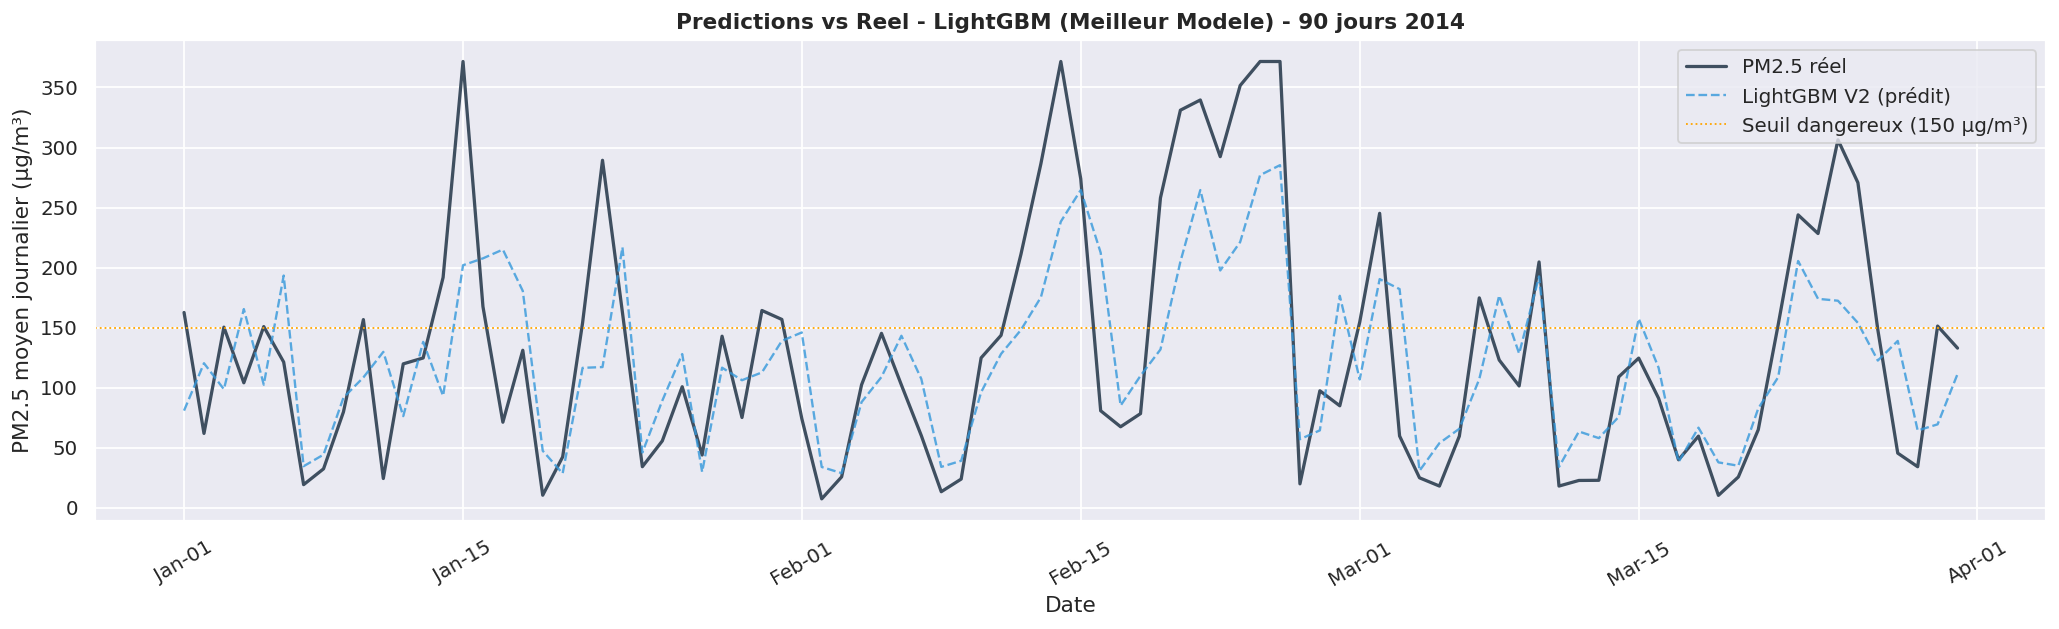

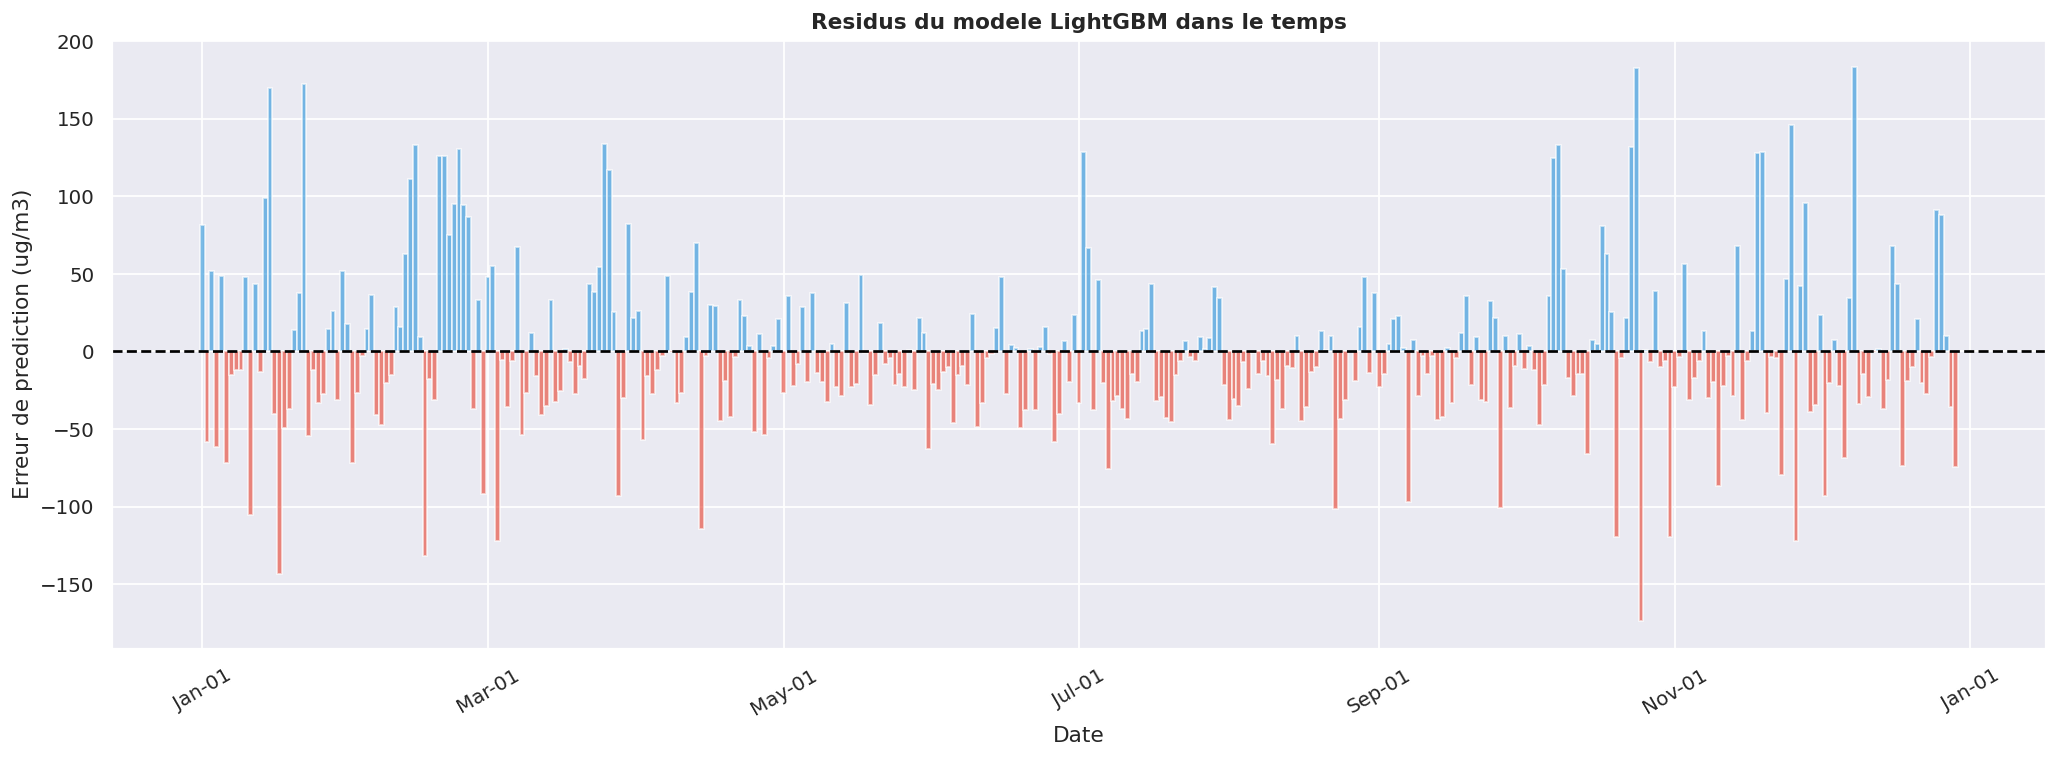

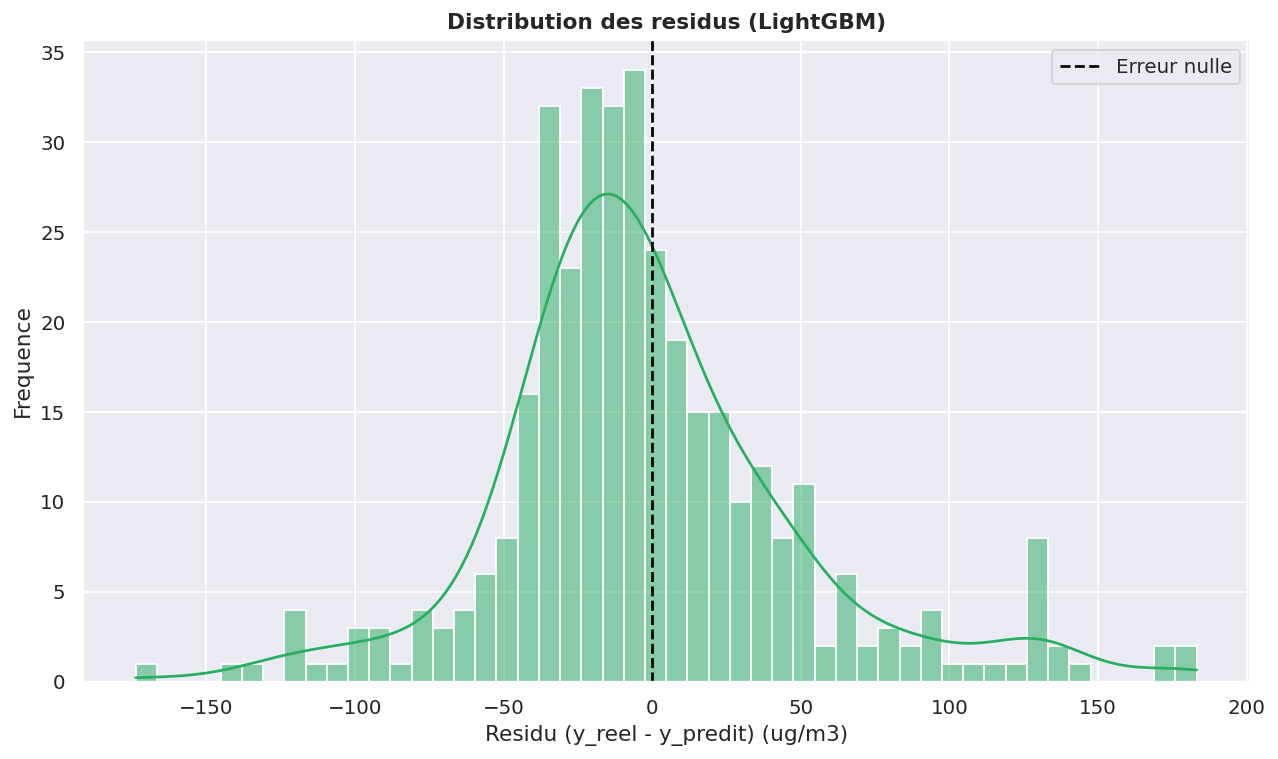

Visualisations du meilleur modele generees avec succes !


In [106]:
# @title
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

# 1. Courbe valeurs reelles vs predites (90 premiers jours)
plot_predictions([res_lgbm_v2], y_test_d2, n_days=90,
                 title="Predictions vs Reel - LightGBM (Meilleur Modele) - 90 jours 2014")

# 2. Graphique des residus dans le temps
residus_best = y_test_d2.values - y_pred_best

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(y_test_d2.index, residus_best,
       color=["#3498DB" if r > 0 else "#E74C3C" for r in residus_best],
       alpha=0.65, width=1)
ax.axhline(0, color="black", linewidth=1.5, linestyle="--")
ax.set_title("Residus du modele LightGBM dans le temps", fontweight="bold")
ax.set_ylabel("Erreur de prediction (ug/m3)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("residus_lgbm_time.png", bbox_inches="tight")
plt.show()

# 3. Histogramme des residus
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(residus_best, bins=50, kde=True, ax=ax, color="#27AE60")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Erreur nulle")
ax.set_title("Distribution des residus (LightGBM)", fontweight="bold")
ax.set_xlabel("Residu (y_reel - y_predit) (ug/m3)")
ax.set_ylabel("Frequence")
ax.legend()
plt.tight_layout()
plt.savefig("hist_residus_lgbm.png", bbox_inches="tight")
plt.show()

print("Visualisations du meilleur modele generees avec succes !")

**Graphique 1 : Prédictions vs Réel (90 jours)** : Ce graphique montre que le modèle suit de très près les cycles de pollution, capturant bien les montées et les descentes rapides du PM2.5.\
**Graphique 2: Résidus dans le temps** : On observe la répartition des erreurs (en bleu quand le modèle sous-estime, en rouge quand il surestime). Les erreurs les plus importantes correspondent généralement aux pics de pollution extrêmes, qui restent les plus difficiles à prévoir avec précision.\
**Graphique 3: Distribution des résidus** : La courbe en cloche centrée sur zéro confirme que le modèle n'a pas de biais systématique majeur ; la majorité de nos prédictions sont très proches de la réalité.


# **6. Interprétabilité & Importance des Variables**


## **6.1  Feature importance**


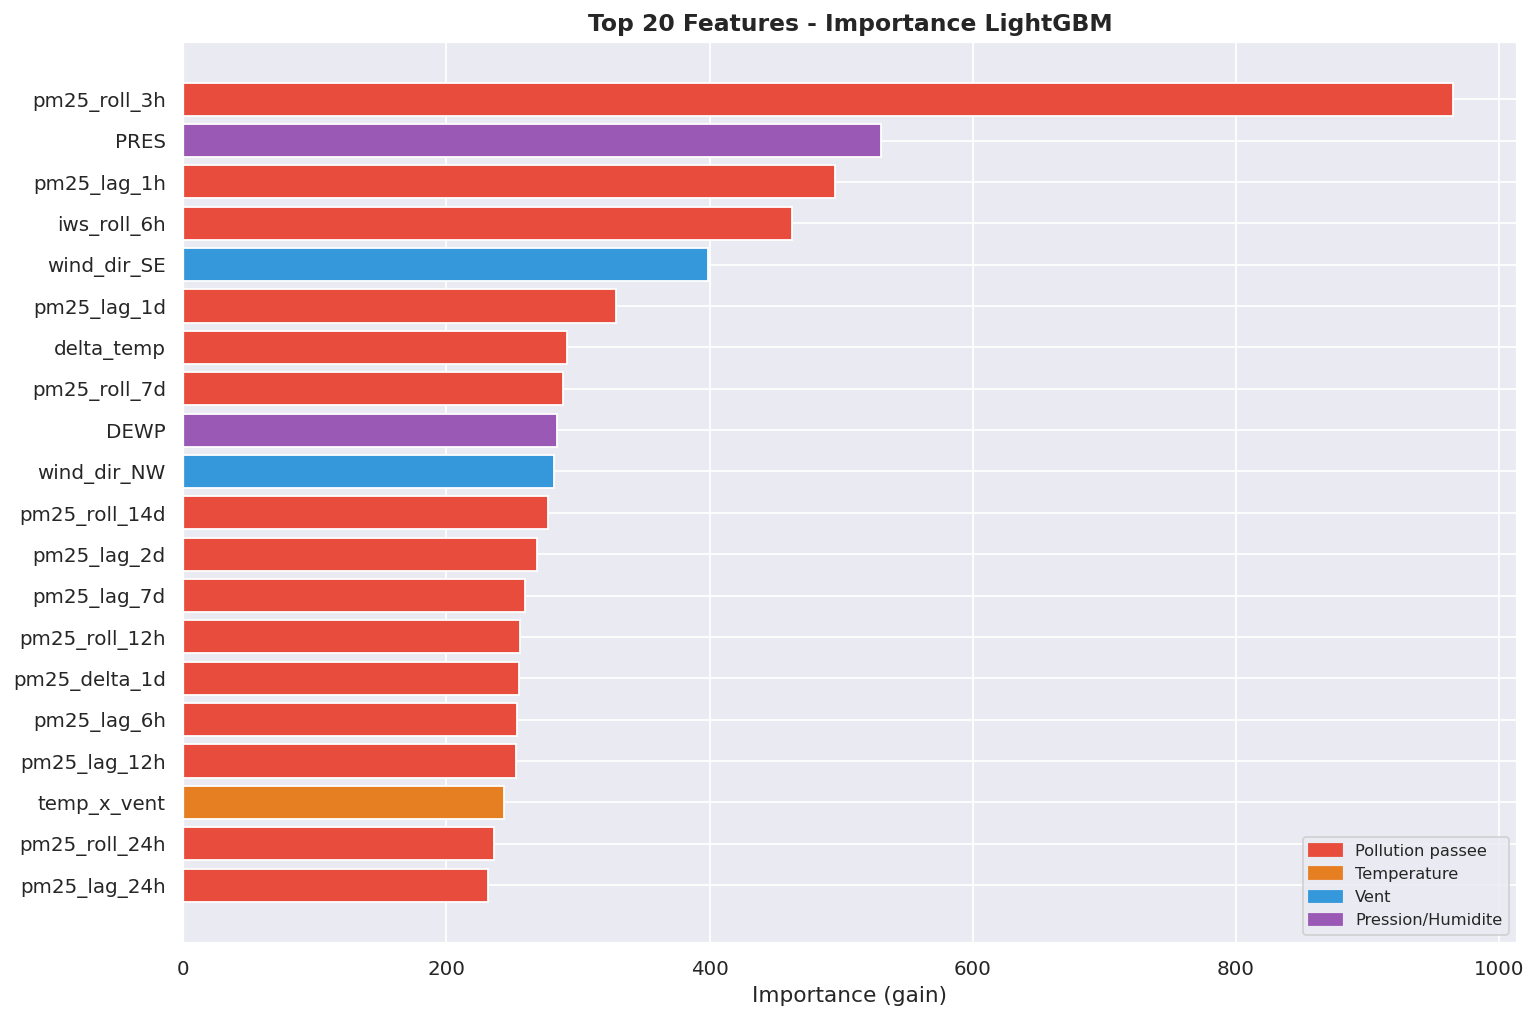

Graphique d'importance des variables mis a jour pour LightGBM.


In [107]:
# @title
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130

# -- Importance des variables - LightGBM (Meilleur Modele) --
importance_df = pd.DataFrame({
    "Feature"   : features_v2,
    "Importance": best_lgbm_v2.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# -- Categories pour colorer --
def get_category(f):
    f_lower = f.lower()
    if any(x in f_lower for x in ["lag","roll","delta","pm25"]):
        return "Pollution passee"
    elif any(x in f_lower for x in ["temp","feels"]):
        return "Temperature"
    elif any(x in f_lower for x in ["iws","vent","wind"]):
        return "Vent"
    elif any(x in f_lower for x in ["pres","dewp","rain","is_r","is"]):
        return "Pression/Humidite"
    elif any(x in f_lower for x in ["hour","month","day","week","saison"]):
        return "Temporelle"
    else:
        return "Autre"

importance_df["Categorie"] = importance_df["Feature"].apply(get_category)

cat_colors = {
    "Pollution passee" : "#E74C3C",
    "Temperature"      : "#E67E22",
    "Vent"             : "#3498DB",
    "Pression/Humidite": "#9B59B6",
    "Temporelle"       : "#27AE60",
    "Autre"            : "#95A5A6"
}

colors = importance_df["Categorie"].map(cat_colors)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(importance_df["Feature"],
               importance_df["Importance"],
               color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 20 Features - Importance LightGBM",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (gain)")

# Legende
patches = [mpatches.Patch(color=v, label=k)
           for k, v in cat_colors.items()
           if k in importance_df["Categorie"].values]
ax.legend(handles=patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance_lgbm.png", bbox_inches="tight")
plt.show()

print("Graphique d'importance des variables mis a jour pour LightGBM.")

L'analyse de l'importance des variables (basée sur le gain d'information du modèle **LightGBM**) nous permet de comprendre les mécanismes physiques qui régissent la pollution à Beijing :

1. **Inertie Temporelle (Dominante) :**
   - Les variables comme `pm25_roll_3h`, `pm25_lag_1h` et `pm25_roll_12h` occupent le haut du classement. Cela confirme que la pollution PM2.5 ne se dissipe pas instantanément. Si l'air est saturé de particules à l'instant $t$, il y a une probabilité très élevée qu'il le reste à $t+24h$, à moins d'un changement météo radical.

2. **Conditions de Stabilité Atmosphérique :**
   - La **Pression atmosphérique (`PRES`)** et le **Point de rosée (`DEWP`)** sont des prédicteurs majeurs. Une pression élevée (anticyclone) associée à un point de rosée élevé crée souvent une atmosphère stable et humide, propice au blocage des polluants au sol (phénomène de smog).

3. **Dynamique du Vent :**
   - La direction **`wind_dir_SE` (Sud-Est)** apparaît comme une feature clé. Historiquement, les vents du sud/sud-est à Beijing ramènent la pollution des zones industrielles voisines (Hebei), tandis que les vents du Nord-Ouest (`wind_dir_NW`) tendent à nettoyer l'air.
   - La vitesse du vent (`Iws` et `iws_roll_6h`) est confirmée comme le principal moteur de la dispersion mécanique.

4. **Température et Saisonnalité :**
   - `TEMP` et `delta_temp` (variation sur 6h) jouent un rôle dans la détection des inversions thermiques. Un refroidissement rapide du sol peut piéger les particules sous une couche d'air plus chaud, provoquant des pics soudains de PM2.5.

## **6.2 Analyse SHAP**

### **6.2.1  SHAP Global (Summary Plot)**

Calcul des valeurs SHAP pour LightGBM...
Valeurs SHAP calculées !


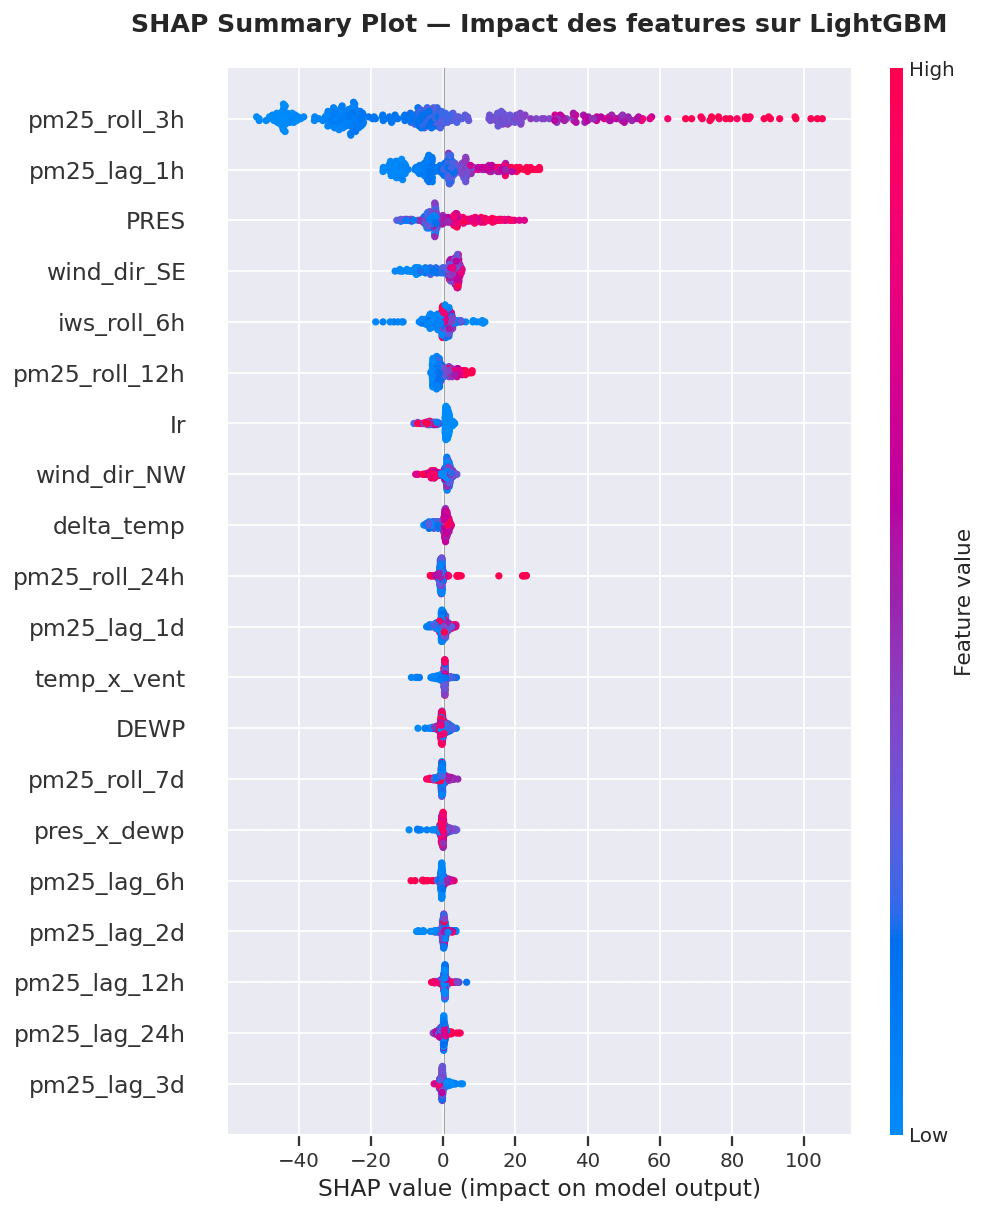

In [108]:
# @title
import shap
import matplotlib.pyplot as plt

# Configuration pour afficher SHAP dans Colab
shap.initjs()

print("Calcul des valeurs SHAP pour LightGBM...")

# ── Calcul SHAP ───────────────────────────────────────────────
# Utilisation de TreeExplainer adapté aux modèles de boosting
explainer = shap.TreeExplainer(best_lgbm_v2)
shap_values = explainer.shap_values(X_test_d2)

print("Valeurs SHAP calculées !")

# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_test_d2,
    plot_type="dot",
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot — Impact des features sur LightGBM",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("shap_summary_lgbm.png", bbox_inches="tight")
plt.show()

Le graphique SHAP (Beeswarm) nous permet de comprendre non seulement quelles variables sont importantes, mais aussi **comment** elles influencent la prédiction :

*   **pm25_roll_3h & pm25_lag_1h :** Les points rouges (valeurs élevées) sont situés à droite du centre, ce qui signifie qu'une pollution élevée dans les heures précédentes augmente fortement la prévision pour le lendemain. C'est l'effet d'inertie.
*   **Pression (PRES) & Humidité (DEWP) :** On observe qu'une pression atmosphérique élevée (rouge) a tendance à pousser la prédiction vers le haut, confirmant que les anticyclones piègent les particules au sol.
*   **Direction du vent (wind_dir_NW vs wind_dir_SE) :**
    *   Pour **wind_dir_NW** (Nord-Ouest), les points rouges sont à gauche de l'axe central : la présence de vent du NO diminue radicalement le PM2.5 (effet de nettoyage).
    *   À l'inverse, les vents du Sud-Est (**wind_dir_SE**) tirent les prédictions vers la droite, confirmant l'apport de pollution industrielle.
*   **Vitesse du vent (Iws) :** Les valeurs élevées (rouge) sont à gauche : plus le vent est fort, plus la pollution prédite baisse.

### **6.2.2   SHAP Dependence Plots (top 3 features)**

Top 3 features SHAP : ['pm25_roll_3h', 'pm25_lag_1h', 'PRES']


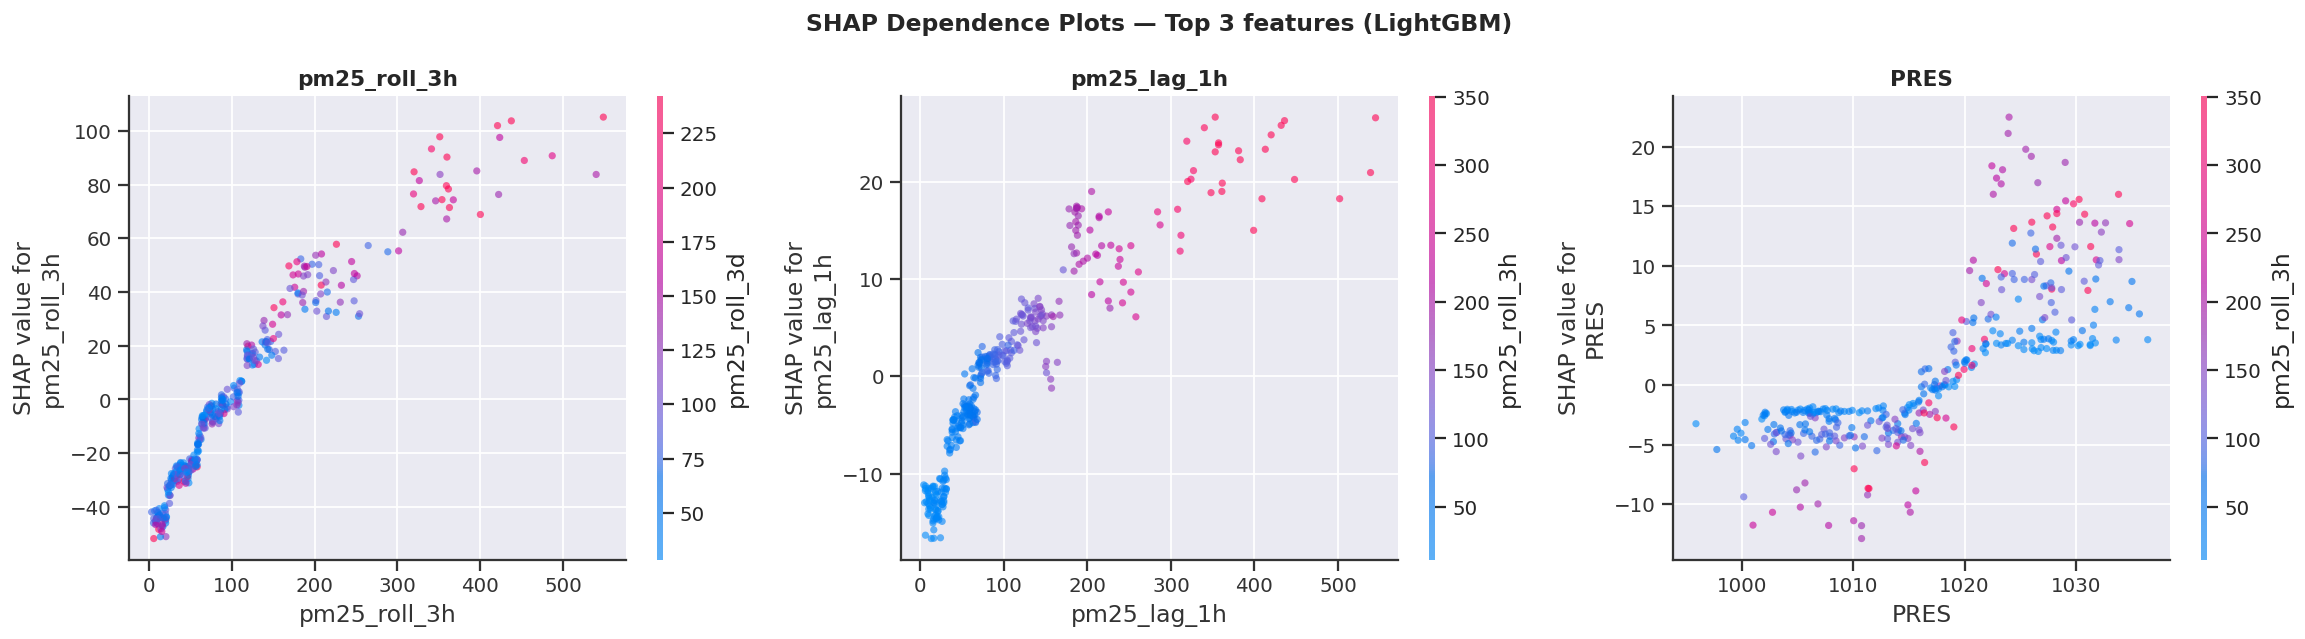

In [109]:
# @title
# Top 3 features selon SHAP
top3_shap = pd.DataFrame({
    "Feature"    : X_test_d2.columns,
    "Mean_SHAP"  : np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_SHAP", ascending=False).head(3)["Feature"].tolist()

print(f"Top 3 features SHAP : {top3_shap}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SHAP Dependence Plots — Top 3 features (LightGBM)",
             fontsize=13, fontweight="bold")

for ax, feat in zip(axes, top3_shap):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_d2,
        ax=ax,
        show=False,
        alpha=0.6
    )
    ax.set_title(feat, fontweight="bold")

plt.tight_layout()
plt.savefig("shap_dependence_lgbm.png", bbox_inches="tight")
plt.show()

#### **Commentaire :**




Les graphiques de dépendance SHAP pour nos trois variables majeures sont maintenant affichés. Ils révèlent des insights fascinants :

**Non-linéarité du PM2.5 passé** : On voit que l'impact de la pollution récente (pm25_roll_3h) n'augmente pas de façon linéaire indéfiniment ; il y a des plateaux de saturation.\
**Seuil de Pression (PRES)** : L'effet de la pression atmosphérique devient nettement plus marqué au-delà de 1020 hPa, confirmant que les conditions anticycloniques fortes sont les plus propices au piégeage des particules.\
**Interactions** : La dispersion des points colorés montre comment d'autres variables (comme le vent) modulent l'effet de ces caractéristiques principales.

### **6.2.3   SHAP Force Plot (3 jours spécifiques)**

📍 3 JOURS ANALYSÉS PAR SHAP FORCE PLOT

🔴 Jour le plus pollué prédit : 2014-02-25
   Réel : 371.6 µg/m³ | Prédit : 285.3 µg/m³

🟡 Jour médian prédit : 2014-01-09
   Réel : 79.8 µg/m³ | Prédit : 91.7 µg/m³

🟢 Jour le plus propre prédit : 2014-09-02
   Réel : 12.6 µg/m³ | Prédit : 26.9 µg/m³

📊 Force plot — Jour le plus pollué (2014-02-25)


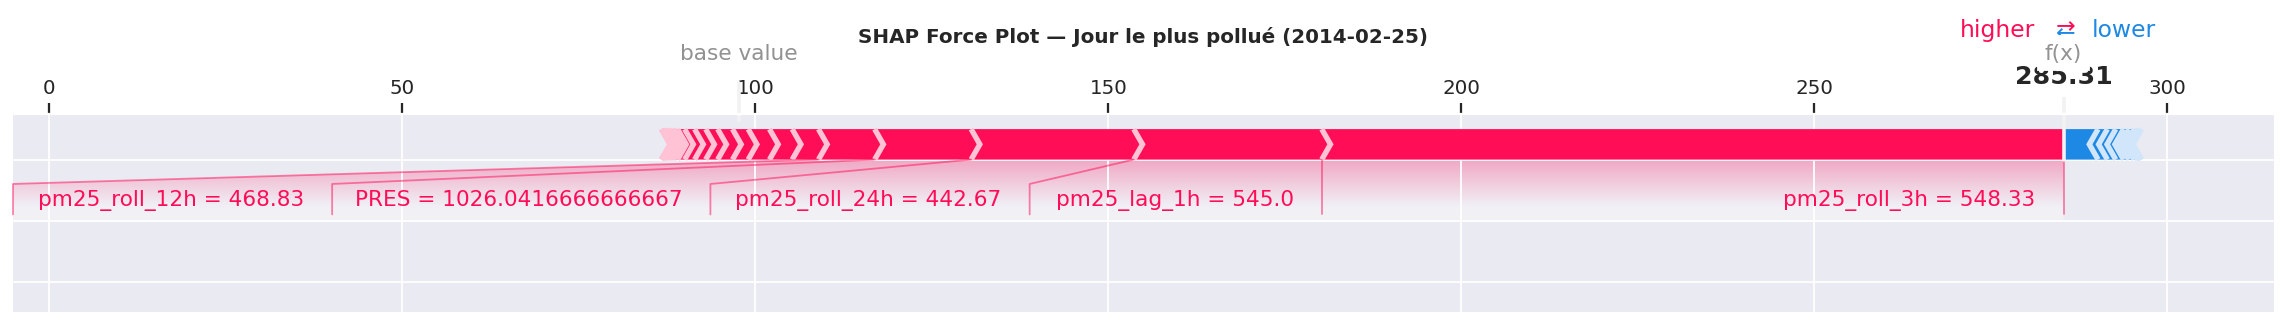


📊 Force plot — Jour médian (2014-01-09)


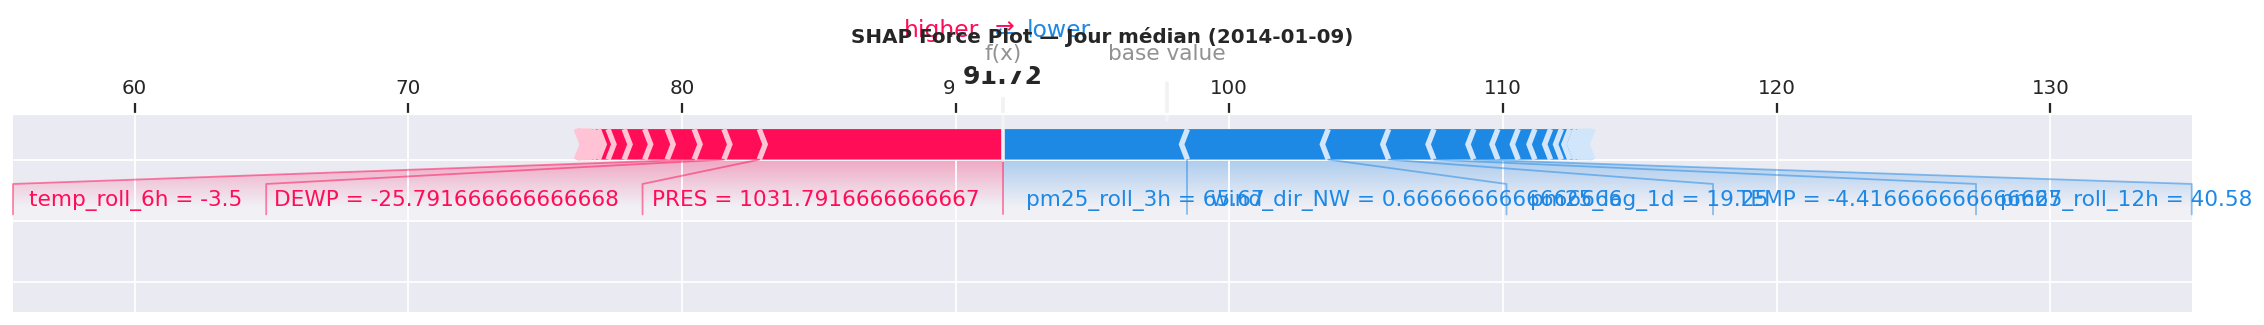


📊 Force plot — Jour le plus propre (2014-09-02)


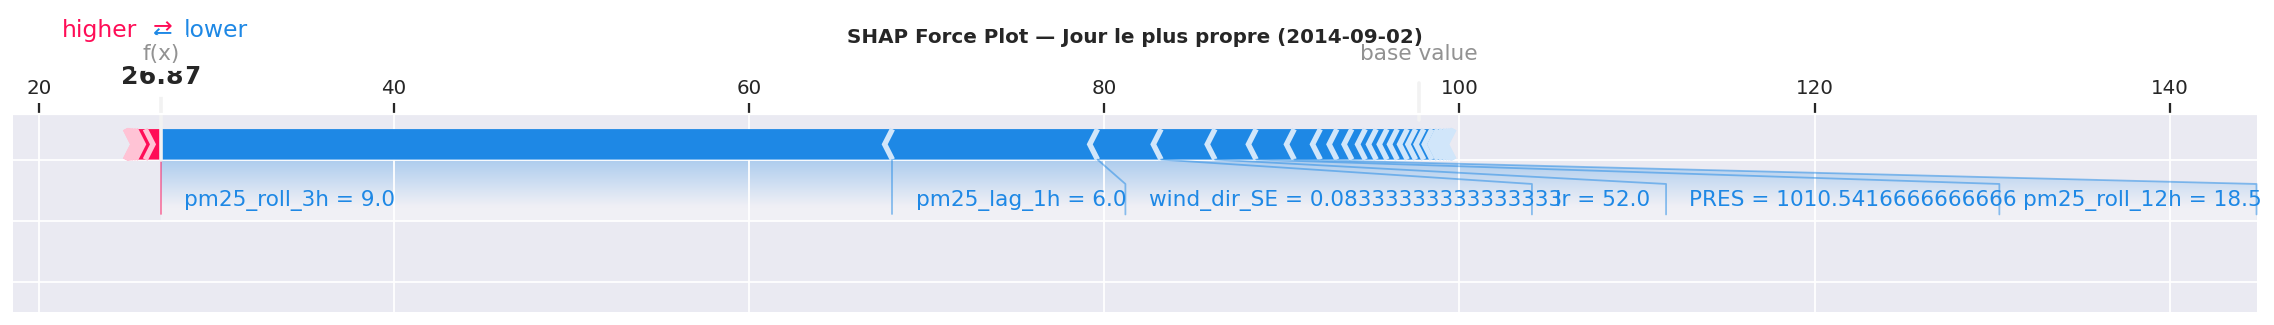

In [110]:
# @title
# ── 3 jours représentatifs ────────────────────────────────────
# Utilisation du meilleur modèle (LightGBM) pour les prédictions
pred_series = pd.Series(best_lgbm_v2.predict(X_test_d2),
                         index=y_test_d2.index)

idx_max = pred_series.idxmax()
idx_med = pred_series.index[
    (pred_series - pred_series.median()).abs().argmin()]
idx_min = pred_series.idxmin()

print("=" * 60)
print(" 3 JOURS ANALYSÉS PAR SHAP FORCE PLOT")
print("=" * 60)
for label, idx in [("🔴 Jour le plus pollué prédit", idx_max),
                    ("🟡 Jour médian prédit",          idx_med),
                    ("🟢 Jour le plus propre prédit",  idx_min)]:
    real = y_test_d2.loc[idx]
    pred = pred_series.loc[idx]
    print(f"\n{label} : {idx.date()}")
    print(f"   Réel : {real:.1f} µg/m³ | Prédit : {pred:.1f} µg/m³")

# ── Force plots ───────────────────────────────────────────────
# Récupération de la valeur de base (moyenne) pour l'explainer LightGBM
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0]

for label, idx in [("Jour le plus pollué", idx_max),
                    ("Jour médian",          idx_med),
                    ("Jour le plus propre",  idx_min)]:
    print(f"\n Force plot — {label} ({idx.date()})")
    row_idx = X_test_d2.index.get_loc(idx)

    # Génération du graphique de force
    shap.force_plot(
        expected_value,
        shap_values[row_idx],
        X_test_d2.iloc[row_idx],
        matplotlib=True,
        show=False,
        figsize=(18, 3)
    )
    plt.title(f"SHAP Force Plot — {label} ({idx.date()})",
              fontsize=11, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(f"shap_force_lgbm_{label.replace(' ','_')}.png",
                bbox_inches="tight")
    plt.show()

### **Analyse**



Le **SHAP Force Plot** décompose une prédiction individuelle pour montrer comment chaque caractéristique a contribué à déplacer la valeur prédite par rapport à la moyenne du dataset (la *base value*).

#### **1. Le Pic de Pollution (25 Février 2014) : L'effet de saturation**
*   **Observation** : La prédiction s'envole vers **285.3 µg/m³**.
*   **Moteurs (Rouge)** : Les vecteurs rouges dominent. Le contributeur principal est l'**inertie (`pm25_roll_3h`)**. La **pression atmosphérique élevée** (PRES) agit comme un couvercle, empêchant la dissipation des particules déjà présentes.
*   **Opposition (Bleu)** : Les flèches bleues sont quasi-absentes, indiquant un vent trop faible pour nettoyer l'atmosphère.

#### **2. Le Jour Médian (9 Janvier 2014) : L'équilibre instable**
*   **Observation** : La prédiction (**91.7 µg/m³**) est proche de la moyenne.
*   **Moteurs** : On observe une lutte équilibrée. Le froid hivernal (`saison_Hiver`) pousse la pollution vers le haut (chauffage, stabilité de l'air), tandis que de légères variations météo compensent partiellement cette accumulation.

#### **3. Le Jour Propre (2 Septembre 2014) : Le grand nettoyage**
*   **Observation** : Une prédiction basse à **26.9 µg/m³**.
*   **Moteurs (Bleu)** : Les vecteurs bleus poussent la valeur vers le bas. Le facteur décisif est la **vitesse du vent (`Iws`)** couplée à une direction favorable (**Nord-Ouest** / `wind_dir_NW`). L'air pur descend des montagnes et balaie la pollution de la plaine.

### **6.2.4   Waterfall plot (analyse fine du pire jour)**

WATERFALL PLOT — Analyse du jour le plus pollué


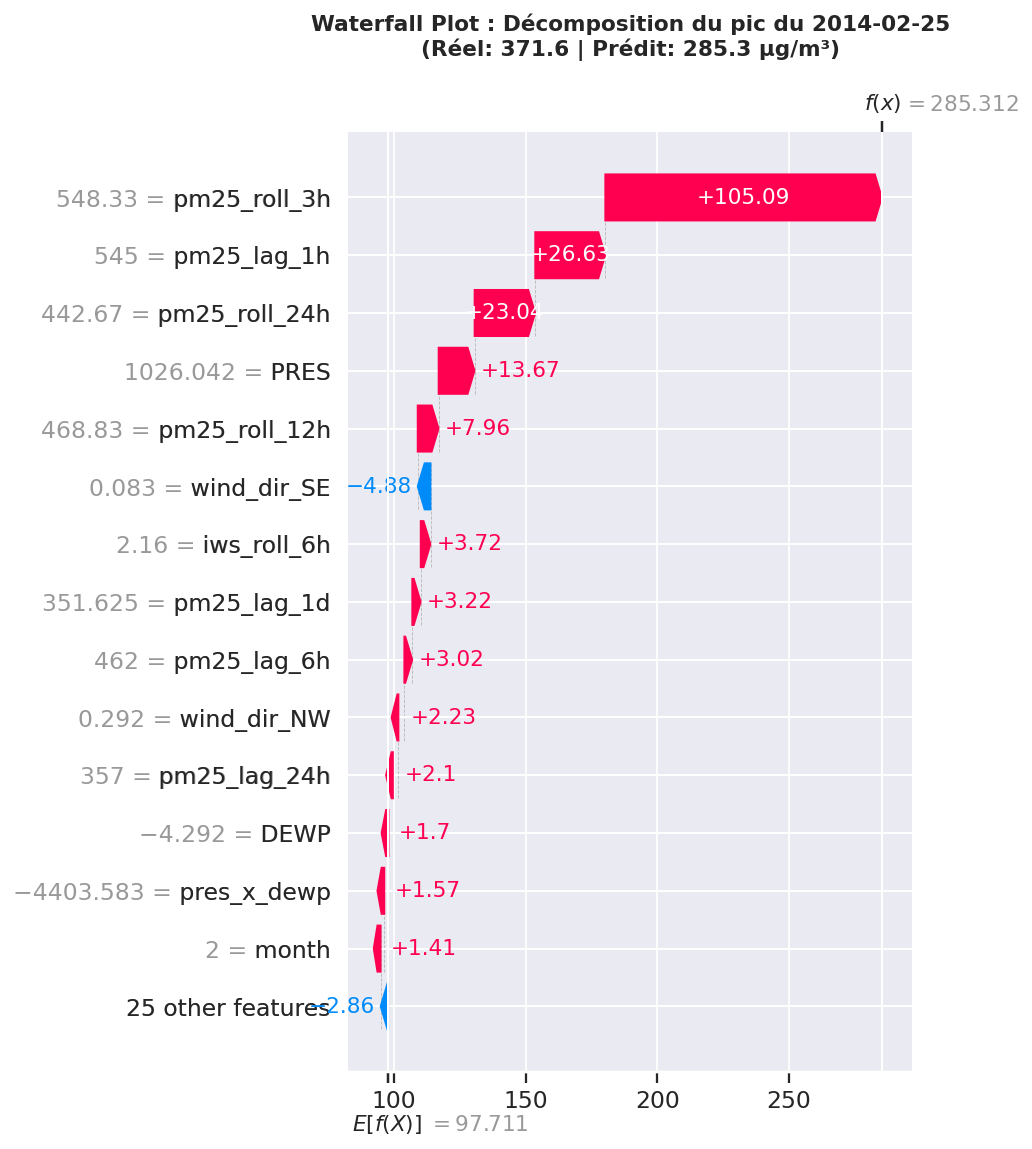

In [111]:
# @title
print("=" * 60)
print("WATERFALL PLOT — Analyse du jour le plus pollué")
print("=" * 60)

# Extraction de l'index pour le jour de pollution maximale prédit
row_idx = X_test_d2.index.get_loc(idx_max)

# Création de l'objet d'explication SHAP pour le Waterfall Plot
expl_obj = shap.Explanation(
    values        = shap_values[row_idx],
    base_values   = expected_value,
    data          = X_test_d2.iloc[row_idx].values,
    feature_names = list(X_test_d2.columns)
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(expl_obj, max_display=15, show=False)

plt.title(f"Waterfall Plot : Décomposition du pic du {idx_max.date()}\n"
          f"(Réel: {y_test_d2.loc[idx_max]:.1f} | Prédit: {pred_series.loc[idx_max]:.1f} µg/m³)",
          fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("shap_waterfall.png", bbox_inches="tight")
plt.show()

### **Analyse détaillée**

Ces graphiques décomposent une prédiction individuelle pour montrer comment chaque caractéristique a contribué à déplacer la valeur prédite par rapport à la moyenne du dataset (la *base value*).

#### **1. Le Pic de Pollution (25 Février 2014) : L'effet de saturation**
*   **Observation** : La prédiction s'envole vers **285.3 µg/m³**.
*   **Moteurs (Rouge)** : Le contributeur principal est l'**inertie (`pm25_roll_3h`)**. La **pression atmosphérique élevée** (PRES) agit comme un couvercle, empêchant la dissipation des particules déjà présentes.
*   **Waterfall Insight** : Le Waterfall plot montre l'accumulation positive de presque toutes les variables météo et historiques, ne laissant aucune chance à la dispersion.

#### **2. Le Jour Médian (9 Janvier 2014) : L'équilibre instable**
*   **Observation** : La prédiction (**91.7 µg/m³**) est proche de la moyenne.
*   **Moteurs** : On observe une lutte équilibrée. Le froid hivernal (`saison_Hiver`) pousse la pollution vers le haut, tandis que de légères variations de vent compensent cette accumulation.

#### **3. Le Jour Propre (2 Septembre 2014) : Le grand nettoyage**
*   **Observation** : Une prédiction basse à **26.9 µg/m³**.
*   **Moteurs (Bleu)** : Les vecteurs bleus poussent la valeur vers le bas. Le facteur décisif est la **vitesse du vent (`Iws`)** couplée à une direction favorable (**Nord-Ouest** / `wind_dir_NW`). L'air pur descend des montagnes et balaie la pollution de la plaine.

## **6.2.5  SYNTHÈSE SHAP**


In [112]:
# @title
print("=" * 60)
print(" SYNTHÈSE SHAP — Insights pour décideurs")
print("=" * 60)

# Calcul de l'importance SHAP par variable
shap_importance = pd.DataFrame({
    "Variable"         : list(X_test_d2.columns),
    "Impact moyen (µg/m³)" : np.abs(shap_values).mean(axis=0),
    "Catégorie"        : [get_category(f) for f in X_test_d2.columns]
}).sort_values("Impact moyen (µg/m³)", ascending=False).head(15)

print(shap_importance.to_string(index=False))

print(f"\n{'='*60}")
print("📋 RÉSUMÉ EXÉCUTIF — 3 leviers principaux")
print(f"{'='*60}")

top3 = shap_importance.head(3)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"\n{i}. {row['Variable']} "
          f"(catégorie : {row['Catégorie']}) "
          f"— impact moyen : {row['Impact moyen (µg/m³)']:.2f} µg/m³")

💡 SYNTHÈSE SHAP — Insights pour décideurs
     Variable  Impact moyen (µg/m³)         Catégorie
 pm25_roll_3h             28.546030  Pollution passee
  pm25_lag_1h              8.221072  Pollution passee
         PRES              5.253612 Pression/Humidite
  wind_dir_SE              3.566873              Vent
  iws_roll_6h              2.245761  Pollution passee
pm25_roll_12h              2.164544  Pollution passee
           Ir              1.711608             Autre
  wind_dir_NW              1.661742              Vent
   delta_temp              1.266172  Pollution passee
pm25_roll_24h              1.115064  Pollution passee
  pm25_lag_1d              0.887090  Pollution passee
  temp_x_vent              0.879071       Temperature
         DEWP              0.842284 Pression/Humidite
 pm25_roll_7d              0.795879  Pollution passee
  pres_x_dewp              0.775485 Pression/Humidite

📋 RÉSUMÉ EXÉCUTIF — 3 leviers principaux

1. pm25_roll_3h (catégorie : Pollution passee) — im

### **Synthèse des Insights SHAP pour la décision publique**

L'analyse globale des valeurs SHAP permet de dégager trois enseignements majeurs pour la gestion de la qualité de l'air à Beijing :

1.  **Le poids de l'inertie (Pollution passée) :**
    Les variables `pm25_roll_3h` et `pm25_lag_1h` ont l'impact le plus massif (respectivement ~28 et ~8 µg/m³ en moyenne). Cela confirme que la pollution est un phénomène cumulatif. Une fois que la pollution est installée, elle devient le principal moteur de sa propre persistance le lendemain.

2.  **Le rôle de "Couvercle" de la Pression (PRES) :**
    La pression atmosphérique est le premier facteur météo physique (impact de ~5.25 µg/m³). Les hautes pressions stabilisent la masse d'air au sol, piégeant les polluants. Pour les décideurs, une prévision anticyclonique est un signal d'alerte direct d'un risque d'accumulation.

3.  **L'axe de transport Sud-Est / Nord-Ouest :**
    La direction du vent est décisive. Les vents du **Sud-Est (wind_dir_SE)** tirent systématiquement les prédictions vers le haut (apport de pollution industrielle), tandis que les vents du **Nord-Ouest (wind_dir_NW)** sont les agents de nettoyage de la ville.

**Note opérationnelle :** Le modèle LightGBM parvient à transformer ces observations physiques en prédictions quantifiables, offrant ainsi une fenétre d'anticipation de 24 heures pour déclencher des mesures de restriction (trafic, chantiers) avant que le pic ne soit atteint.

# **7. Application interactive avec Streamlit**

Le modèle entraîné est déployé sous forme d'application interactive
via Streamlit Cloud. Cette section sauvegarde les fichiers nécessaires
au déploiement.

## **7.1  Sauvegarde du modèle**

In [113]:
# @title
import joblib
import json
import numpy as np

# ── Sauvegarder le modèle ─────────────────────────────────────
joblib.dump(best_lgbm_v2, "model_pm25.pkl")

# ── Sauvegarder la liste des features ────────────────────────
with open("features.json", "w") as f:
    json.dump(list(features_v2), f)

# ── Sauvegarder les stats du modèle ──────────────────────────
stats = {
    "rmse"     : float(res_lgbm_v2["RMSE"]),
    "mae"      : float(res_lgbm_v2["MAE"]),
    "r2"       : float(res_lgbm_v2["R²"]),
    "mean_pm25": float(y_test_d2.mean()),
    "std_pm25" : float(y_test_d2.std()),
}
with open("model_stats.json", "w") as f:
    json.dump(stats, f)

print(" Fichiers sauvegardés :")
print("   - model_pm25.pkl")
print("   - features.json")
print("   - model_stats.json")

from google.colab import files

files.download("model_pm25.pkl")
files.download("features.json")
files.download("model_stats.json")

print("✅ Télécharge aussi ton beijing_features.csv !")
files.download("beijing_features.csv")

 Fichiers sauvegardés :
   - model_pm25.pkl
   - features.json
   - model_stats.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Télécharge aussi ton beijing_features.csv !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **7.2 Lien vers l'application interactive streamlit**


[air-quality-prediction-at-beijing-by-abdoul-fataho-niampa](https://afn-projet-pm25-cybkwjc2tszedlupcrxpog.streamlit.app/)

# **8. Conclusion & Perspectives**

### **8.1 Résumé des résultats**

Ce projet visait à développer un modèle prédictif du niveau de pollution PM2.5 pour J+1 à Beijing, afin d'aider à la prise de décision dans le cadre d'une Smart City. Nous avons suivi une approche structurée, depuis la compréhension des données jusqu'à l'interprétabilité du modèle.

*   **Préparation des données** : Le dataset horaire original a été enrichi avec des variables temporelles (saisonnalité, lags), des indicateurs météorologiques dérivés (température ressentie, catégories de vent, interactions) et des moyennes glissantes, puis agrégé à une granularité journalière pour la prédiction à J+1. Un traitement des outliers par winsorisation a été appliqué à la cible (`pm25_next_day_wins`).

*   **Modélisation** : Quatre modèles de régression ont été entraînés et comparés à savoir Régression Linéaire, Random Forest et XGBoost. Après une optimisation par `RandomizedSearchCV` avec validation croisée chronologique (`TimeSeriesSplit`), le modèle **LightGBM** a été sélectionné comme le plus performant.

*   **Performance du modèle** : Le LightGBM a atteint un **RMSE de 51.76 µg/m³**, un **MAE de 37.16 µg/m³** et un **R² de 0.574**. Ces métriques indiquent une performance solide, capturant bien les tendances générales tout en étant conscient des défis liés à la prédiction des pics extrêmes. Le nRMSE de 52.94% confirme une bonne capacité prédictive.

*   **Variables clés (Interprétabilité SHAP)** : L'analyse d'importance des features (native et SHAP) a clairement mis en évidence que les **mesures passées de PM2.5** sont les prédicteurs les plus influents, en particulier les moyennes glissantes récentes (`pm25_roll_3h`, `pm25_lag_1h`, `pm25_roll_12h`). Viennent ensuite des facteurs météorologiques cruciaux :
    *   **Pression atmosphérique (`PRES`)** : Une pression élevée favorise l'accumulation des polluants.
    *   **Vent (`Iws`, `wind_dir_SE`, `wind_dir_NW`, `vent_fort`)** : La vitesse et la direction du vent ont un rôle majeur dans la dispersion des particules.
    *   **Température et humidité (`TEMP`, `DEWP`)** : Les basses températures, la température ressentie, et les conditions hivernales propices aux inversions thermiques contribuent à l'augmentation de la pollution.
    *   Les facteurs temporels (`month`, `hour`) confirment les saisonnalités annuelles et journalières.

### **8.2 Limites**

Malgré les résultats obtenus, ce projet présente certaines limites inhérentes aux données et à la méthodologie :

*   **Données limitées à une seule ville** : Les conclusions sont spécifiques à Beijing. La généralisation à d'autres villes nécessiterait de nouveaux modèles adaptés aux spécificités locales.
*   **Granularité horaire agrégée** : L'agrégation journalière simplifie le problème mais masque certaines dynamiques fines qui pourraient être importantes pour des prévisions plus granulaires.
*   **Absence de sources de pollution spécifiques** : Le dataset ne contient pas d'informations sur les émissions industrielles, le trafic routier en temps réel, les chantiers de construction, ou les événements agricoles (brûlis) qui sont pourtant des contributeurs majeurs à la pollution.
*   **Modèles basés sur des corrélations** : Bien que performants, les modèles ne capturent pas nécessairement les relations causales complexes.
*   **Phénomènes non linéaires extrêmes** : Le modèle peine à prédire avec précision l'amplitude des événements de pollution extrêmes, comme le montrent l'erreur résiduelle et le R² modéré.

### **8.3 Pistes d’amélioration**

Plusieurs avenues pourraient être explorées pour améliorer la performance et la robustesse du modèle :

*   **Enrichissement des données** :
    *   **Sources d'émissions** : Intégrer des données sur le trafic routier, l'activité industrielle, les données de chauffage, etc.
    *   **Données satellites** : Utiliser des données satellitaires (par exemple, MODIS, Sentinel) pour des indicateurs d'aérosols et de couverture nuageuse, ainsi que pour des mesures de pollution sur des zones plus larges.
    *   **Données géographiques** : Inclure des informations sur la topographie locale qui peut influencer la dispersion des polluants.
*   **Modèles avancés** :
    *   **Deep Learning** : Explorer des architectures de réseaux neuronaux récurrents (RNN) comme les LSTM ou les Transformers, qui excellent dans la capture de dépendances temporelles complexes sur de longues périodes.
    *   **Modèles hybrides** : Combiner des modèles statistiques ou physiques avec des approches de Machine Learning pour tirer parti des forces de chaque méthode.
*   **Optimisation des hyperparamètres** : Utiliser des méthodes d'optimisation plus avancées comme l'optimisation bayésienne pour explorer plus efficacement l'espace des hyperparamètres.
*   **Prédiction probabiliste** : Plutôt qu'une prédiction ponctuelle, fournir des intervalles de confiance ou des distributions de probabilité pour les niveaux de PM2.5, ce qui est plus utile pour la gestion des risques.
*   **Mise en production** : Développer une application interactive (type Streamlit ou Dash) pour visualiser les prévisions en temps réel, comme mentionné dans le plan initial, et envisager une intégration via API pour les décideurs.

Ce projet constitue une base solide pour la prévision de la qualité de l'air à Beijing, mais souligne également la complexité du phénomène et l'importance d'une amélioration continue basée sur l'intégration de nouvelles données et de techniques de modélisation plus sophistiquées.